<a href="https://colab.research.google.com/github/JGaldeano96/TFM-Pedestrian-Traffic-Light/blob/develop/notebooks/CNN_test.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Declaración sobre el uso de Inteligencia Artificial Generativa

El desarrollo del código contenido en este notebook ha contado con la asistencia de herramientas de Inteligencia Artificial Generativa como apoyo en tareas de implementación, revisión, refactorización y mejora de determinadas partes del código.

No obstante, la concepción y desarrollo del proyecto han sido realizados por el autor. Esto incluye la definición de la arquitectura general de la solución, el diseño de los pipelines de procesamiento y entrenamiento, la selección y configuración de modelos y algoritmos, la preparación y estructuración de los datos, el diseño de los experimentos, la elección de métricas y criterios de evaluación, así como la definición de los procedimientos de validación y análisis de resultados.

Las propuestas de código obtenidas mediante herramientas de IA generativa no han sido incorporadas de forma automática. Todo el código utilizado en este proyecto ha sido revisado, comprendido, adaptado, integrado y probado por el autor, quien ha verificado su correcto funcionamiento y su adecuación a los objetivos y requisitos definidos para el proyecto.

Asimismo, las decisiones técnicas y metodológicas, la interpretación de los resultados, la resolución de errores, la comparación entre alternativas y la selección final de las soluciones implementadas han sido responsabilidad exclusiva del autor.

Por tanto, la Inteligencia Artificial Generativa ha sido utilizada como una herramienta de apoyo al desarrollo, sin sustituir el criterio técnico, el proceso de diseño, la validación experimental ni la toma de decisiones del autor.

# Librerías

In [1]:
import math
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Image as IPythonImage
from IPython.display import Video, display
from PIL import Image, ImageDraw
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore

I0000 00:00:1788874126.085030  811817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788874126.461411  811817 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788874128.469931  811817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Configuración de rutas

In [2]:
ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

RESULTS_DIR = ROOT_DIR / "results" / "classifier"
TEST_RESULTS_DIR = RESULTS_DIR / "test"
REPORT_DIR = ROOT_DIR / "report"

MODEL_PATH = RESULTS_DIR / "dataset_v2" / "classifier_v2" / "best.keras"
VAL_DIR = ROOT_DIR / "data" / "datasets" / "classifier" / "val"
CLASSIFIER_TEST_DIR = ROOT_DIR / "data" / "datasets" / "classifier_test"

VALIDATION_PREDICTION_PATHS = {
    "dataset_v1": RESULTS_DIR / "dataset_v1" / "classifier_v1" / "predictions_dataset_v1.csv",
    "dataset_v2": RESULTS_DIR / "dataset_v2" / "classifier_v2" / "predictions_dataset_v2.csv",
}

TEST_METRICS_PATH = TEST_RESULTS_DIR / "cnn_test_metrics.csv"
TEST_THRESHOLD_METRICS_PATH = TEST_RESULTS_DIR / "cnn_test_threshold_metrics.csv"
TEST_PREDICTION_PATHS = {
    "dataset_v1_diurn": TEST_RESULTS_DIR / "predictions_dataset_v1_diurn.csv",
    "dataset_v1_nocturn": TEST_RESULTS_DIR / "predictions_dataset_v1_nocturn.csv",
    "dataset_v2_diurn": TEST_RESULTS_DIR / "predictions_dataset_v2_diurn.csv",
    "dataset_v2_nocturn": TEST_RESULTS_DIR / "predictions_dataset_v2_nocturn.csv",
}

# VALIDATION ANALYSIS

In [3]:
df_v1 = pd.read_csv(
    VALIDATION_PREDICTION_PATHS["dataset_v1"]
)


df_v2 = pd.read_csv(
    VALIDATION_PREDICTION_PATHS["dataset_v2"]
)


df_v1["dataset"] = "dataset_v1"


df_v2["dataset"] = "dataset_v2"


df = pd.concat(
    [
        df_v1,
        df_v2,
    ],
    ignore_index=True,
)


df

,filename,filepath,true_label,true_class,predicted_label,predicted_class,probability_green,threshold,error_type,dataset
0,000002_frame000001_tdWqnzsoW5.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.988784,0.5,correct,dataset_v1
1,000002_frame000002_gAfLmaPpQX.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.989176,0.5,correct,dataset_v1
2,000002_frame000003_rYdAr2L_qh.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.924877,0.5,correct,dataset_v1
3,000002_frame000004_T-MZ98wc_M.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.986626,0.5,correct,dataset_v1
4,000002_frame000005_k2-TrHuyer.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.987089,0.5,correct,dataset_v1
...,...,...,...,...,...,...,...,...,...,...
2922,000110_frame000012_Ywgr1CqQ4L.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.000801,0.5,correct,dataset_v2
2923,000110_frame000013_LnMZTlt1sY.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.001353,0.5,correct,dataset_v2
2924,000110_frame000013_xnGsoIhg0o.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.000503,0.5,correct,dataset_v2
2925,000110_frame000014_8SZBiczhPb.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.000644,0.5,correct,dataset_v2


In [4]:
# ============================================================
# THRESHOLDS
# ============================================================

THRESHOLD_V1 = 0.046506

THRESHOLD_V2 = 0.8


# ============================================================
# FUNCIÓN DE MÉTRICAS
# ============================================================

def calculate_metrics(
    df_dataset: pd.DataFrame,
    threshold: float,
    dataset_name: str,
) -> dict:

    # --------------------------------------------------------
    # Etiquetas reales
    # --------------------------------------------------------

    y_true = df_dataset[
        "true_label"
    ].to_numpy()

    # --------------------------------------------------------
    # Probabilidad de Green
    # --------------------------------------------------------

    y_scores = df_dataset[
        "probability_green"
    ].to_numpy()

    # --------------------------------------------------------
    # Predicción
    #
    # 0 -> Red
    # 1 -> Green
    # --------------------------------------------------------

    y_pred = (
        y_scores >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Matriz de confusión
    # --------------------------------------------------------

    TN, FP, FN, TP = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    accuracy = (
        (TP + TN)
        / (TP + TN + FP + FN)
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    false_positive_rate = (
        FP / (FP + TN)
        if (FP + TN) > 0
        else 0
    )

    false_negative_rate = (
        FN / (FN + TP)
        if (FN + TP) > 0
        else 0
    )

    false_green_rate = (
        FP / (FP + TN)
        if (FP + TN) > 0
        else 0
    )

    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    roc_auc = roc_auc_score(
        y_true,
        y_scores,
    )

    # --------------------------------------------------------
    # Youden
    #
    # Se calcula solamente como referencia.
    # NO determina el threshold utilizado.
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_scores,
    )

    youden_scores = (
        tpr - fpr
    )

    youden_threshold = thresholds[
        np.argmax(youden_scores)
    ]

    # --------------------------------------------------------
    # Resultado
    # --------------------------------------------------------

    return {

        "threshold": threshold,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "specificity": specificity,

        "false_positive_rate": false_positive_rate,

        "false_negative_rate": false_negative_rate,

        "false_green_rate": false_green_rate,

        "TN": TN,

        "FP": FP,

        "FN": FN,

        "TP": TP,

        "roc_auc": roc_auc,

        "youden_threshold": youden_threshold,

        "dataset": dataset_name,

        "num_images": len(df_dataset),
    }


# ============================================================
# CALCULAR MÉTRICAS
# ============================================================

results = []


# ------------------------------------------------------------
# DATASET V1
# ------------------------------------------------------------

df_v1 = df[
    df["dataset"] == "dataset_v1"
]


results.append(
    calculate_metrics(
        df_dataset=df_v1,
        threshold=THRESHOLD_V1,
        dataset_name="dataset_v1",
    )
)


# ------------------------------------------------------------
# DATASET V2
# ------------------------------------------------------------

df_v2 = df[
    df["dataset"] == "dataset_v2"
]


results.append(
    calculate_metrics(
        df_dataset=df_v2,
        threshold=THRESHOLD_V2,
        dataset_name="dataset_v2",
    )
)


# ============================================================
# DATAFRAME FINAL
# ============================================================

metrics_df = pd.DataFrame(
    results
)


metrics_df

,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP,roc_auc,youden_threshold,dataset,num_images
0,0.046506,0.991194,0.997727,0.982103,0.989853,0.998261,0.001739,0.017897,0.001739,574,1,8,439,0.997996,0.046506,dataset_v1,1022
1,0.800000,0.997900,1.000000,0.995134,0.997561,1.000000,0.000000,0.004866,0.000000,1083,0,4,818,0.999978,0.089264,dataset_v2,1905


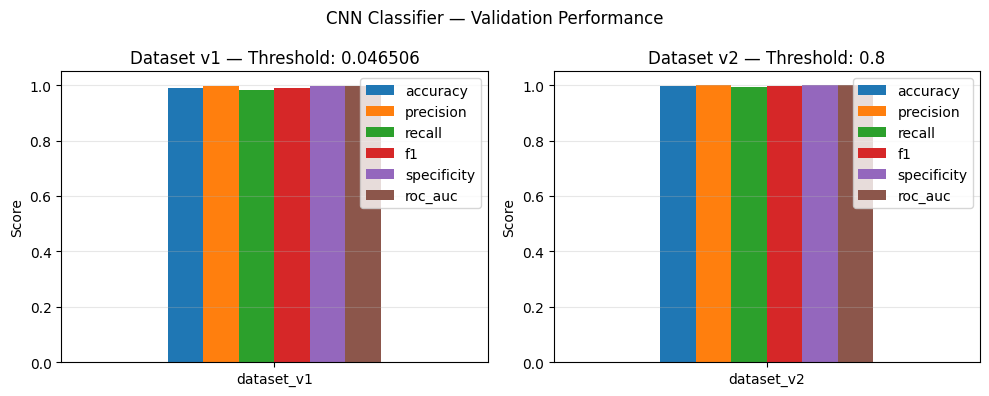

In [5]:
# ============================================================
# GRÁFICOS — MÉTRICAS POR DATASET
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "roc_auc",
]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)


# ============================================================
# DATASET V1
# ============================================================

v1_df = metrics_df[
    metrics_df["dataset"] == "dataset_v1"
].set_index("dataset")[metrics]


v1_df.plot(
    kind="bar",
    ax=axes[0],
)


axes[0].set_title(
    f"Dataset v1 — Threshold: {THRESHOLD_V1}"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)

axes[0].tick_params(
    axis="x",
    rotation=0,
)

axes[0].grid(
    axis="y",
    alpha=0.3,
)


# ============================================================
# DATASET V2
# ============================================================

v2_df = metrics_df[
    metrics_df["dataset"] == "dataset_v2"
].set_index("dataset")[metrics]


v2_df.plot(
    kind="bar",
    ax=axes[1],
)


axes[1].set_title(
    f"Dataset v2 — Threshold: {THRESHOLD_V2}"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)

axes[1].tick_params(
    axis="x",
    rotation=0,
)

axes[1].grid(
    axis="y",
    alpha=0.3,
)


# ============================================================
# AJUSTES
# ============================================================

fig.suptitle(
    "CNN Classifier — Validation Performance",
    fontsize=12,
)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# MÉTRICAS POR THRESHOLD
# ============================================================

threshold_results = []

thresholds = np.round(
    np.arange(
        0.00,
        1.01,
        0.01,
    ),
    2,
)


# ============================================================
# FUNCIÓN
# ============================================================

def calculate_threshold_metrics(
    df_dataset: pd.DataFrame,
    threshold: float,
    dataset_name: str,
) -> dict:

    y_true = df_dataset[
        "true_label"
    ].to_numpy()

    y_scores = df_dataset[
        "probability_green"
    ].to_numpy()

    y_pred = (
        y_scores >= threshold
    ).astype(int)

    TN, FP, FN, TP = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    accuracy = (
        (TP + TN)
        / (TP + TN + FP + FN)
    )

    precision = (
        TP / (TP + FP)
        if TP + FP > 0
        else 0
    )

    recall = (
        TP / (TP + FN)
        if TP + FN > 0
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP > 0
        else 0
    )

    false_positive_rate = (
        FP / (FP + TN)
        if FP + TN > 0
        else 0
    )

    false_negative_rate = (
        FN / (FN + TP)
        if FN + TP > 0
        else 0
    )

    false_green_rate = false_positive_rate

    return {

        "dataset": dataset_name,

        "threshold": threshold,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "specificity": specificity,

        "false_positive_rate": false_positive_rate,

        "false_negative_rate": false_negative_rate,

        "false_green_rate": false_green_rate,

        "TN": TN,

        "FP": FP,

        "FN": FN,

        "TP": TP,
    }


# ============================================================
# DATASET V1
# ============================================================

df_v1 = df[
    df["dataset"] == "dataset_v1"
]


for threshold in thresholds:

    threshold_results.append(
        calculate_threshold_metrics(
            df_dataset=df_v1,
            threshold=threshold,
            dataset_name="dataset_v1",
        )
    )


# ============================================================
# DATASET V2
# ============================================================

df_v2 = df[
    df["dataset"] == "dataset_v2"
]


for threshold in thresholds:

    threshold_results.append(
        calculate_threshold_metrics(
            df_dataset=df_v2,
            threshold=threshold,
            dataset_name="dataset_v2",
        )
    )


# ============================================================
# DATAFRAME FINAL
# ============================================================

threshold_metrics_df = pd.DataFrame(
    threshold_results
)


threshold_metrics_df.head()

,dataset,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP
0,dataset_v1,0.00,0.437378,0.437378,1.000000,0.608577,0.000000,1.000000,0.000000,1.000000,0,575,0,447
1,dataset_v1,0.01,0.983366,0.967391,0.995526,0.981257,0.973913,0.026087,0.004474,0.026087,560,15,2,445
2,dataset_v1,0.02,0.986301,0.982183,0.986577,0.984375,0.986087,0.013913,0.013423,0.013913,567,8,6,441
3,dataset_v1,0.03,0.989237,0.990991,0.984340,0.987654,0.993043,0.006957,0.015660,0.006957,571,4,7,440
4,dataset_v1,0.04,0.989237,0.993213,0.982103,0.987627,0.994783,0.005217,0.017897,0.005217,572,3,8,439


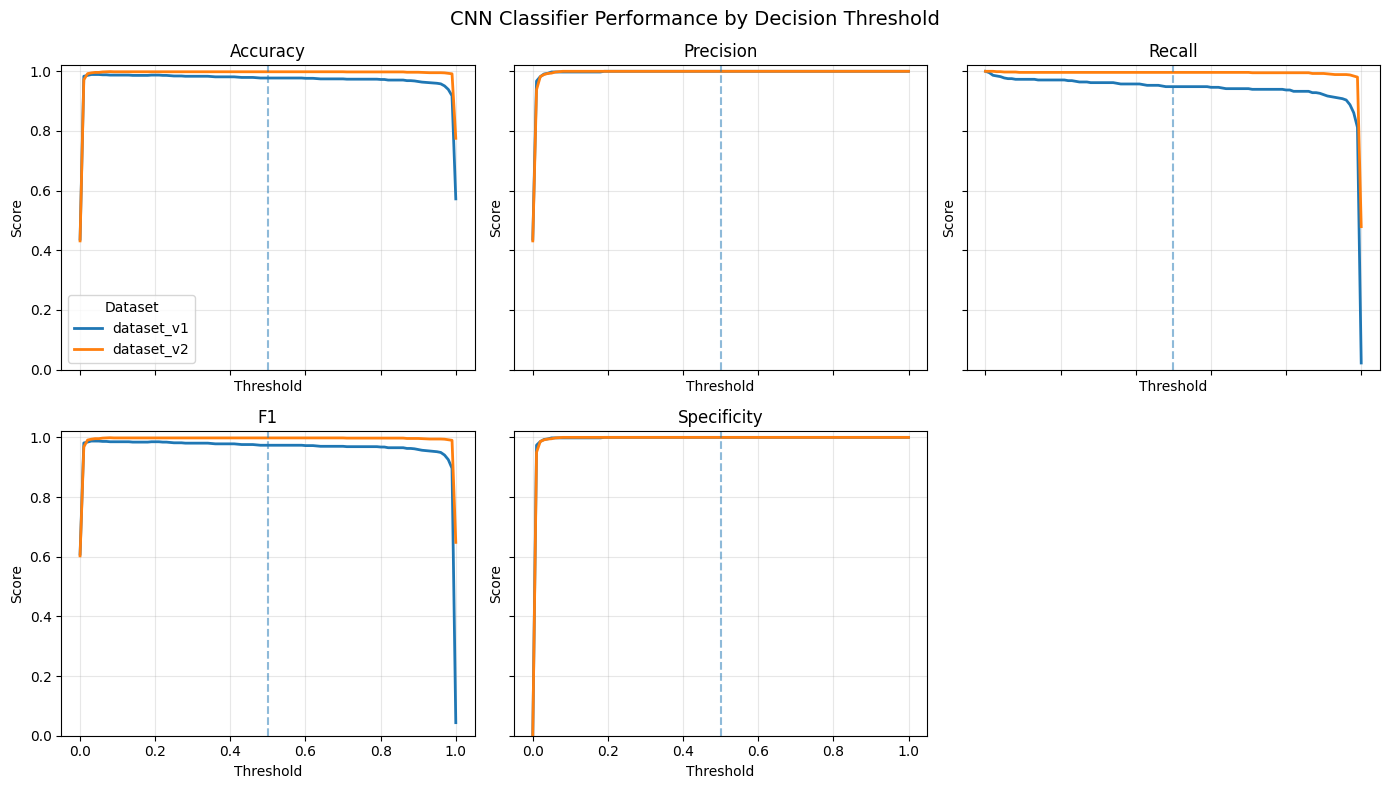

In [7]:
# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
]

datasets = sorted(
    threshold_metrics_df["dataset"].unique()
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 8),
    sharex=True,
    sharey=True,
)


axes = axes.flatten()


# ============================================================
# PLOTS
# ============================================================

for col, metric in enumerate(metrics):

    ax = axes[col]

    for dataset in datasets:

        data = threshold_metrics_df[
            threshold_metrics_df["dataset"] == dataset
        ].sort_values(
            "threshold"
        )

        ax.plot(
            data["threshold"],
            data[metric],
            label=dataset,
            linewidth=2,
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        metric.capitalize()
    )

    ax.set_xlabel(
        "Threshold"
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_ylim(
        0,
        1.02,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Threshold 0.5
    # --------------------------------------------------------

    ax.axvline(
        0.5,
        linestyle="--",
        alpha=0.5,
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    if col == 0:

        ax.legend(
            title="Dataset"
        )


# ============================================================
# OCULTAR GRÁFICO SOBRANTE
# ============================================================

axes[-1].set_visible(False)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "CNN Classifier Performance by Decision Threshold",
    fontsize=14,
)

fig.tight_layout()

plt.show()

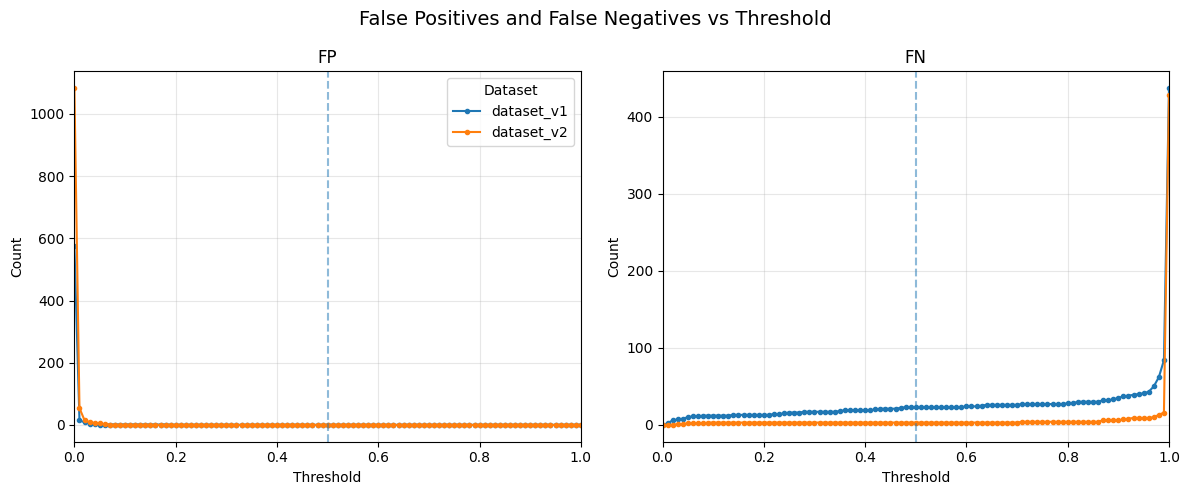

In [8]:
# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "FP",
    "FN",
]

datasets = [
    "dataset_v1",
    "dataset_v2",
]


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
    sharex=True,
)


# ============================================================
# PLOTS
# ============================================================

for col, metric in enumerate(metrics):

    ax = axes[col]

    for dataset in datasets:

        df_dataset = threshold_metrics_df[
            threshold_metrics_df["dataset"] == dataset
        ].sort_values(
            "threshold"
        )

        ax.plot(
            df_dataset["threshold"],
            df_dataset[metric],
            marker="o",
            markersize=3,
            label=dataset,
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        metric
    )

    ax.set_xlabel(
        "Threshold"
    )

    ax.set_ylabel(
        "Count"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.set_xlim(
        0,
        1,
    )

    # --------------------------------------------------------
    # Threshold 0.5
    # --------------------------------------------------------

    ax.axvline(
        0.5,
        linestyle="--",
        alpha=0.5,
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    if col == 0:

        ax.legend(
            title="Dataset"
        )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "False Positives and False Negatives vs Threshold",
    fontsize=14,
)

fig.tight_layout()

plt.show()

dataset_v1 Youden threshold: 0.0465
dataset_v2 Youden threshold: 0.0893


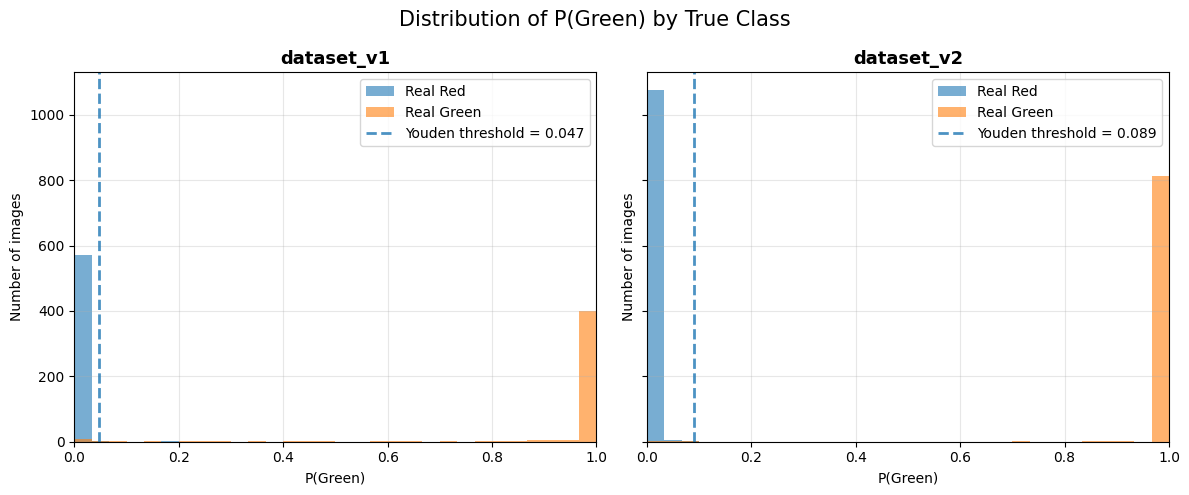

In [9]:
# ============================================================
# CONFIGURATION
# ============================================================

datasets = [
    "dataset_v1",
    "dataset_v2",
]


# ============================================================
# CALCULATE YOUDEN THRESHOLD
#
# Un único threshold por modelo utilizando todo su dataset.
# ============================================================

thresholds = {}


for dataset in datasets:

    df_dataset = df[
        df["dataset"] == dataset
    ]

    # --------------------------------------------------------
    # True labels
    #
    # Red   -> 0
    # Green -> 1
    # --------------------------------------------------------

    y_true = (
        df_dataset["true_label"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # Model output
    #
    # P(Green)
    # --------------------------------------------------------

    y_scores = (
        df_dataset["probability_green"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # ROC
    # --------------------------------------------------------

    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_scores,
    )

    # --------------------------------------------------------
    # Remove infinite threshold
    # --------------------------------------------------------

    valid = np.isfinite(
        roc_thresholds
    )

    fpr = fpr[valid]
    tpr = tpr[valid]
    roc_thresholds = roc_thresholds[valid]

    # --------------------------------------------------------
    # Youden's J
    #
    # J = TPR - FPR
    # --------------------------------------------------------

    youden = (
        tpr - fpr
    )

    best_index = np.argmax(
        youden
    )

    best_threshold = float(
        roc_thresholds[best_index]
    )

    thresholds[dataset] = (
        best_threshold
    )

    print(
        f"{dataset} Youden threshold: "
        f"{best_threshold:.4f}"
    )


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
    sharex=True,
    sharey=True,
)


# ============================================================
# PLOTS
# ============================================================

for ax, dataset in zip(
    axes,
    datasets,
):

    df_dataset = df[
        df["dataset"] == dataset
    ]

    threshold = thresholds[
        dataset
    ]

    # --------------------------------------------------------
    # Real Red
    # --------------------------------------------------------

    red = df_dataset.loc[
        df_dataset["true_class"] == "Red",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Real Green
    # --------------------------------------------------------

    green = df_dataset.loc[
        df_dataset["true_class"] == "Green",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Histograms
    # --------------------------------------------------------

    ax.hist(
        red,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Red",
    )

    ax.hist(
        green,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Green",
    )

    # --------------------------------------------------------
    # Youden threshold
    # --------------------------------------------------------

    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=(
            f"Youden threshold = "
            f"{threshold:.3f}"
        ),
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        dataset,
        fontsize=13,
        fontweight="bold",
    )

    ax.set_xlabel(
        "P(Green)"
    )

    ax.set_ylabel(
        "Number of images"
    )

    ax.set_xlim(
        0,
        1,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Distribution of P(Green) by True Class",
    fontsize=15,
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

plt.show()

En el dataset_v1 el modelo está obligado a funcionar con thresholds bajos ya que incrementarlo supone asumir muchos falsos negativos. Sin embargo, el modelo con dataset_v2 demuestra una mejora significativa a la hora de separar las dos clases de manera que podemos desplazar el threshold sin que suponga una pérdida de la eficacia ni un exceso de falsos negativos. De hecho hasta 0.7 aproximadamente no aumentaría ninguno.

El problema es que al haber tan pocos errores, el punto de Youden puede volverse inestable y no considero que sea una métrica a tener en cuenta. Es por esta razón que, para el dataset v2 usaremos un threshold más alto para asegurar que el modelo es cauto en la clasificación de semaforos y probablemente quede fijado en alrededor de 0.8.

No obstante, los resultados con el test de validación son muy positivos en ambos modelos aunque claramente la ventaja comentada nos hace inclinarnos sobre el modelo en su segunda versión.

## INTERPRETABILIDAD EN VALIDACION

I0000 00:00:1788874131.860158  811817 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5580 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Grad-CAM layer: conv_8


I0000 00:00:1788874133.654775  811817 cuda_dnn.cc:461] Loaded cuDNN version 92400


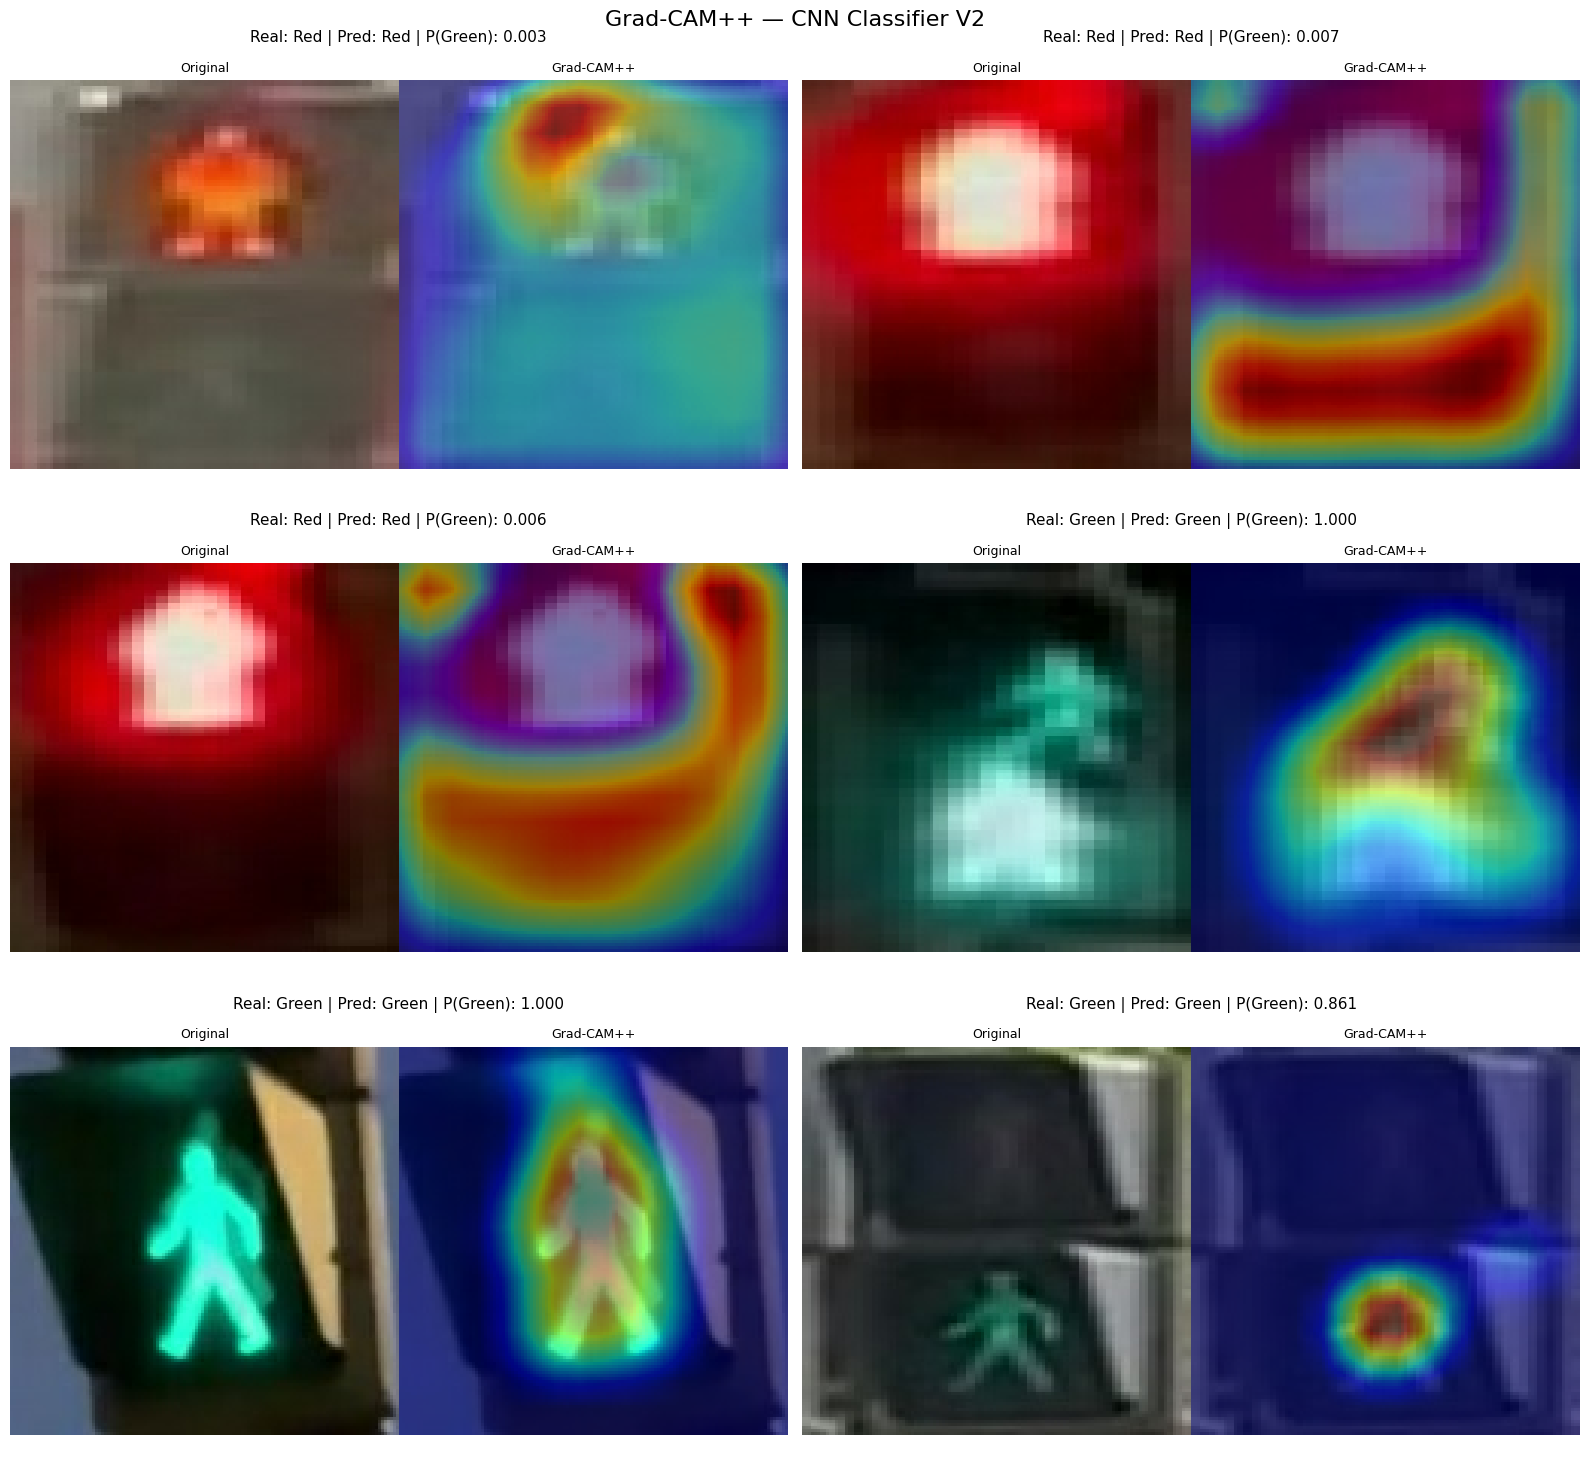

In [10]:
# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_SIZE = (128, 128)

THRESHOLD = 0.8

N_PER_CLASS = 3

COLS = 2


# ============================================================
# LOAD MODEL
# ============================================================

model = tf.keras.models.load_model(
    MODEL_PATH
)


# ============================================================
# LAST CONVOLUTIONAL LAYER
# ============================================================

conv_layers = [
    layer.name
    for layer in model.layers
    if isinstance(
        layer,
        tf.keras.layers.Conv2D,
    )
]

PENULTIMATE_LAYER = conv_layers[-1]

print(
    f"Grad-CAM layer: "
    f"{PENULTIMATE_LAYER}"
)


# ============================================================
# SELECT CORRECT PREDICTIONS
#
# 0 -> Red
# 1 -> Green
# ============================================================

df_gradcam = df_v2.copy()

df_gradcam["pred_label"] = (
    df_gradcam["probability_green"] >= THRESHOLD
).astype(int)

df_gradcam = df_gradcam[
    df_gradcam["true_label"]
    ==
    df_gradcam["pred_label"]
]


# ============================================================
# SAMPLE RED / GREEN
# ============================================================

red_sample = df_gradcam[
    df_gradcam["true_label"] == 0
].sample(
    n=N_PER_CLASS,
    random_state=42,
)

green_sample = df_gradcam[
    df_gradcam["true_label"] == 1
].sample(
    n=N_PER_CLASS,
    random_state=42,
)

samples = pd.concat(
    [
        red_sample,
        green_sample,
    ],
    ignore_index=True,
)


# ============================================================
# GRAD-CAM++
# ============================================================

gradcam = GradcamPlusPlus(
    model=model,
    model_modifier=ReplaceToLinear(),
    clone=True,
)


# ============================================================
# FIGURE
# ============================================================

N_IMAGES = len(samples)

ROWS = int(
    np.ceil(
        N_IMAGES / COLS
    )
)

fig = plt.figure(
    figsize=(
        8 * COLS,
        5 * ROWS,
    )
)


# ============================================================
# PLOTS
# ============================================================

for i, (_, row) in enumerate(
    samples.iterrows()
):

    true_label = int(
        row["true_label"]
    )

    pred_label = int(
        row["pred_label"]
    )

    probability_green = float(
        row["probability_green"]
    )

    true_class = (
        "Red"
        if true_label == 0
        else "Green"
    )

    predicted_class = (
        "Red"
        if pred_label == 0
        else "Green"
    )

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image_path = (
        VAL_DIR
        / true_class
        / row["filename"]
    )

    # Misma carga que image_dataset_from_directory() en las métricas.
    image = tf.io.decode_image(
        tf.io.read_file(str(image_path)),
        channels=3,
        expand_animations=False,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear",
    ).numpy()

    image_input = tf.expand_dims(
        image,
        axis=0,
    )

    # --------------------------------------------------------
    # Grad-CAM++
    # --------------------------------------------------------

    cam = gradcam(
        BinaryScore(
            bool(pred_label)
        ),
        image_input,
        penultimate_layer=PENULTIMATE_LAYER,
    )

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    img = image.astype(
        np.uint8
    )

    heatmap = np.uint8(
        cm.jet(
            cam[0]
        )[..., :3]
        * 255
    )

    # --------------------------------------------------------
    # Plot cell
    # --------------------------------------------------------

    outer = fig.add_subplot(
        ROWS,
        COLS,
        i + 1,
    )

    outer.axis(
        "off"
    )

    outer.set_title(
        f"Real: {true_class} | "
        f"Pred: {predicted_class} | "
        f"P(Green): {probability_green:.3f}",
        fontsize=11,
    )

    left = outer.inset_axes(
        [
            0,
            0,
            0.5,
            1,
        ]
    )

    right = outer.inset_axes(
        [
            0.5,
            0,
            0.5,
            1,
        ]
    )

    left.imshow(
        img
    )

    left.axis(
        "off"
    )

    left.set_title(
        "Original",
        fontsize=9,
    )

    right.imshow(
        img
    )

    right.imshow(
        heatmap,
        alpha=0.5,
    )

    right.axis(
        "off"
    )

    right.set_title(
        "Grad-CAM++",
        fontsize=9,
    )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Grad-CAM++ — CNN Classifier V2",
    fontsize=16,
)

plt.tight_layout()

plt.show()

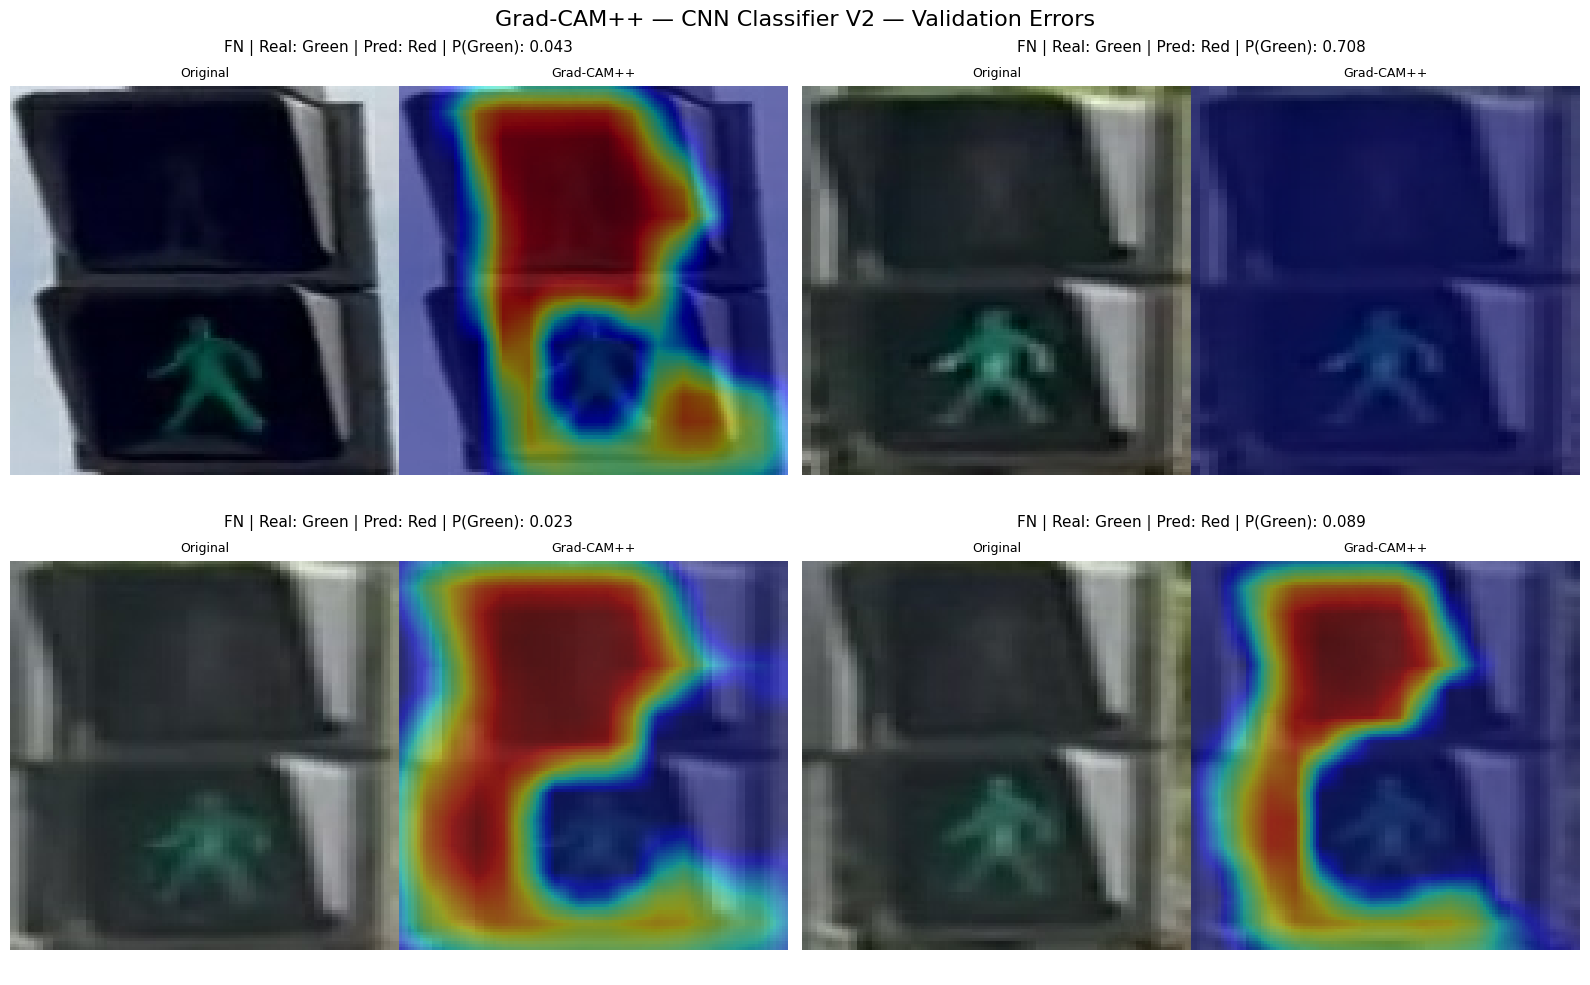

In [11]:
# ============================================================
# VALIDATION ERRORS — GRAD-CAM++
# ============================================================

df_errors = df_v2.copy()

df_errors["pred_label"] = (
    df_errors["probability_green"] >= THRESHOLD
).astype(int)

df_errors = df_errors[
    df_errors["true_label"]
    !=
    df_errors["pred_label"]
].copy()


# ============================================================
# ERROR TYPE
#
# FP -> Red real / Green predicho
# FN -> Green real / Red predicho
# ============================================================

df_errors["error_type"] = np.where(
    (
        (df_errors["true_label"] == 0)
        &
        (df_errors["pred_label"] == 1)
    ),
    "FP",
    "FN",
)


# ============================================================
# FIGURE
# ============================================================

if len(df_errors) > 0:

    N_IMAGES = len(df_errors)

    ROWS = int(
        np.ceil(
            N_IMAGES / COLS
        )
    )

    fig = plt.figure(
        figsize=(
            8 * COLS,
            5 * ROWS,
        )
    )


    # ========================================================
    # PLOTS
    # ========================================================

    for i, (_, row) in enumerate(
        df_errors.iterrows()
    ):

        true_label = int(
            row["true_label"]
        )

        pred_label = int(
            row["pred_label"]
        )

        probability_green = float(
            row["probability_green"]
        )

        true_class = (
            "Red"
            if true_label == 0
            else "Green"
        )

        predicted_class = (
            "Red"
            if pred_label == 0
            else "Green"
        )


        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        image_path = (
            VAL_DIR
            / true_class
            / row["filename"]
        )

        # Misma carga que image_dataset_from_directory() en las métricas.
        image = tf.io.decode_image(
            tf.io.read_file(str(image_path)),
            channels=3,
            expand_animations=False,
        )

        image = tf.image.resize(
            image,
            IMAGE_SIZE,
            method="bilinear",
        ).numpy()

        image_input = tf.expand_dims(
            image,
            axis=0,
        )


        # ----------------------------------------------------
        # Grad-CAM++
        #
        # Se explica la clase incorrectamente predicha
        # por el modelo.
        # ----------------------------------------------------

        cam = gradcam(
            BinaryScore(
                bool(
                    pred_label
                )
            ),
            image_input,
            penultimate_layer=PENULTIMATE_LAYER,
        )


        # ----------------------------------------------------
        # Heatmap
        # ----------------------------------------------------

        img = image.astype(
            np.uint8
        )

        heatmap = np.uint8(
            cm.jet(
                cam[0]
            )[..., :3]
            * 255
        )


        # ----------------------------------------------------
        # Plot cell
        # ----------------------------------------------------

        outer = fig.add_subplot(
            ROWS,
            COLS,
            i + 1,
        )

        outer.axis(
            "off"
        )

        outer.set_title(
            f"{row['error_type']} | "
            f"Real: {true_class} | "
            f"Pred: {predicted_class} | "
            f"P(Green): {probability_green:.3f}",
            fontsize=11,
        )


        # ----------------------------------------------------
        # Original
        # ----------------------------------------------------

        left = outer.inset_axes(
            [
                0,
                0,
                0.5,
                1,
            ]
        )

        left.imshow(
            img
        )

        left.axis(
            "off"
        )

        left.set_title(
            "Original",
            fontsize=9,
        )


        # ----------------------------------------------------
        # Grad-CAM++
        # ----------------------------------------------------

        right = outer.inset_axes(
            [
                0.5,
                0,
                0.5,
                1,
            ]
        )

        right.imshow(
            img
        )

        right.imshow(
            heatmap,
            alpha=0.5,
        )

        right.axis(
            "off"
        )

        right.set_title(
            "Grad-CAM++",
            fontsize=9,
        )


    # ========================================================
    # TITLE
    # ========================================================

    fig.suptitle(
        "Grad-CAM++ — CNN Classifier V2 — Validation Errors",
        fontsize=16,
    )

    plt.tight_layout()

    plt.show()

# TEST ANALYSIS

In [12]:
TEST_RESULTS_DIR

PosixPath('/home/jgaldeano/tfm/results/classifier/test')

In [13]:
RESULTS_DIR

PosixPath('/home/jgaldeano/tfm/results/classifier')

In [14]:
df = pd.read_csv(TEST_METRICS_PATH)

print(df.columns)
df

Index(['threshold', 'accuracy', 'precision', 'recall', 'f1', 'specificity',
       'false_positive_rate', 'false_negative_rate', 'false_green_rate', 'TN',
       'FP', 'FN', 'TP', 'roc_auc', 'youden_threshold', 'dataset', 'test_type',
       'model_path', 'num_images'],
      dtype='object')


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP,roc_auc,youden_threshold,dataset,test_type,model_path,num_images
0,0.047,0.973039,0.964865,0.975410,0.970109,0.971111,0.028889,0.024590,0.028889,437,13,9,357,0.998142,0.040782,dataset_v1,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
1,0.047,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.994767,dataset_v1,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119
2,0.800,0.997549,0.997268,0.997268,0.997268,0.997778,0.002222,0.002732,0.002222,449,1,1,365,0.999976,0.876829,dataset_v2,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
3,0.800,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.999999,dataset_v2,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119


## Análisis comparativo: métricas generales

In [15]:
df = pd.read_csv(TEST_METRICS_PATH)

print(df.columns)
df

Index(['threshold', 'accuracy', 'precision', 'recall', 'f1', 'specificity',
       'false_positive_rate', 'false_negative_rate', 'false_green_rate', 'TN',
       'FP', 'FN', 'TP', 'roc_auc', 'youden_threshold', 'dataset', 'test_type',
       'model_path', 'num_images'],
      dtype='object')


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP,roc_auc,youden_threshold,dataset,test_type,model_path,num_images
0,0.047,0.973039,0.964865,0.975410,0.970109,0.971111,0.028889,0.024590,0.028889,437,13,9,357,0.998142,0.040782,dataset_v1,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
1,0.047,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.994767,dataset_v1,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119
2,0.800,0.997549,0.997268,0.997268,0.997268,0.997778,0.002222,0.002732,0.002222,449,1,1,365,0.999976,0.876829,dataset_v2,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
3,0.800,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.999999,dataset_v2,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119


In [16]:
# ============================================================
# RESUMEN GLOBAL DEL CLASIFICADOR
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "roc_auc",
]

summary_df = (
    df[
        [
            "dataset",
            "test_type",
            *metrics,
        ]
    ]
    .sort_values(
        ["dataset", "test_type"]
    )
    .reset_index(drop=True)
)

summary_df

,dataset,test_type,accuracy,precision,recall,f1,specificity,roc_auc
0,dataset_v1,diurn,0.973039,0.964865,0.975410,0.970109,0.971111,0.998142
1,dataset_v1,nocturn,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,dataset_v2,diurn,0.997549,0.997268,0.997268,0.997268,0.997778,0.999976
3,dataset_v2,nocturn,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


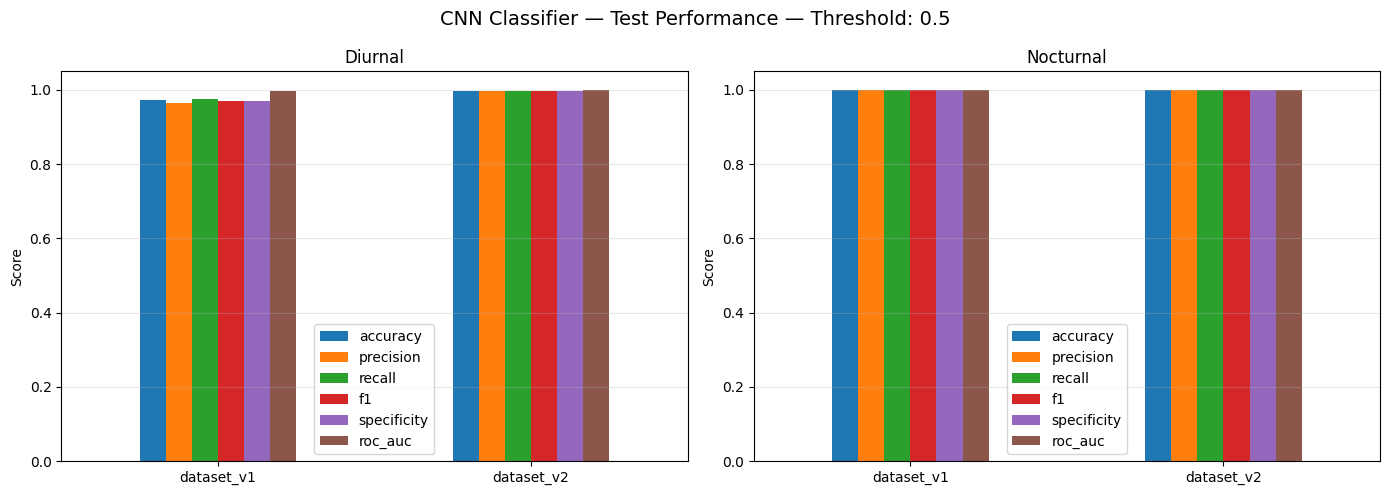

In [17]:
# ============================================================
# GRÁFICO — MÉTRICAS GLOBALES
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "roc_auc",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

# ============================================================
# DIURNO
# ============================================================

diurn_df = summary_df[
    summary_df["test_type"] == "diurn"
].set_index("dataset")[metrics]

diurn_df.plot(
    kind="bar",
    ax=axes[0],
)

axes[0].set_title("Diurnal")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(
    axis="y",
    alpha=0.3,
)

# ============================================================
# NOCTURNO
# ============================================================

nocturn_df = summary_df[
    summary_df["test_type"] == "nocturn"
].set_index("dataset")[metrics]

nocturn_df.plot(
    kind="bar",
    ax=axes[1],
)

axes[1].set_title("Nocturnal")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(
    axis="y",
    alpha=0.3,
)

fig.suptitle(
    "CNN Classifier — Test Performance — Threshold: 0.5",
    fontsize=14,
)

plt.tight_layout()
plt.show()

Se observa que en dataset_v1 el recall es considerablemente bajo (que porcentaje de verdes detectamos correctamente) mientras que la specificity es muy elevada (que porcentaje de rojos detectamos correctamente)

La mejora que aporta dataset_v2 es visible en todas las métricas.

In [18]:
df_threshold = pd.read_csv(TEST_THRESHOLD_METRICS_PATH)

print(df_threshold.columns)


df_threshold

Index(['dataset', 'test_type', 'threshold', 'accuracy', 'precision', 'recall',
       'f1', 'specificity', 'false_positive_rate', 'false_negative_rate',
       'false_green_rate', 'TN', 'FP', 'FN', 'TP'],
      dtype='object')


,dataset,test_type,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP
0,dataset_v1,diurn,0.00,0.448529,0.448529,1.000000,0.619289,0.000000,1.000000,0.000000,1.000000,0,450,0,366
1,dataset_v1,diurn,0.01,0.964461,0.928753,0.997268,0.961792,0.937778,0.062222,0.002732,0.062222,422,28,1,365
2,dataset_v1,diurn,0.02,0.965686,0.940104,0.986339,0.962667,0.948889,0.051111,0.013661,0.051111,427,23,5,361
3,dataset_v1,diurn,0.03,0.969363,0.947507,0.986339,0.966533,0.955556,0.044444,0.013661,0.044444,430,20,5,361
4,dataset_v1,diurn,0.04,0.977941,0.965241,0.986339,0.975676,0.971111,0.028889,0.013661,0.028889,437,13,5,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,dataset_v2,nocturn,0.96,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504
400,dataset_v2,nocturn,0.97,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504
401,dataset_v2,nocturn,0.98,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504
402,dataset_v2,nocturn,0.99,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504


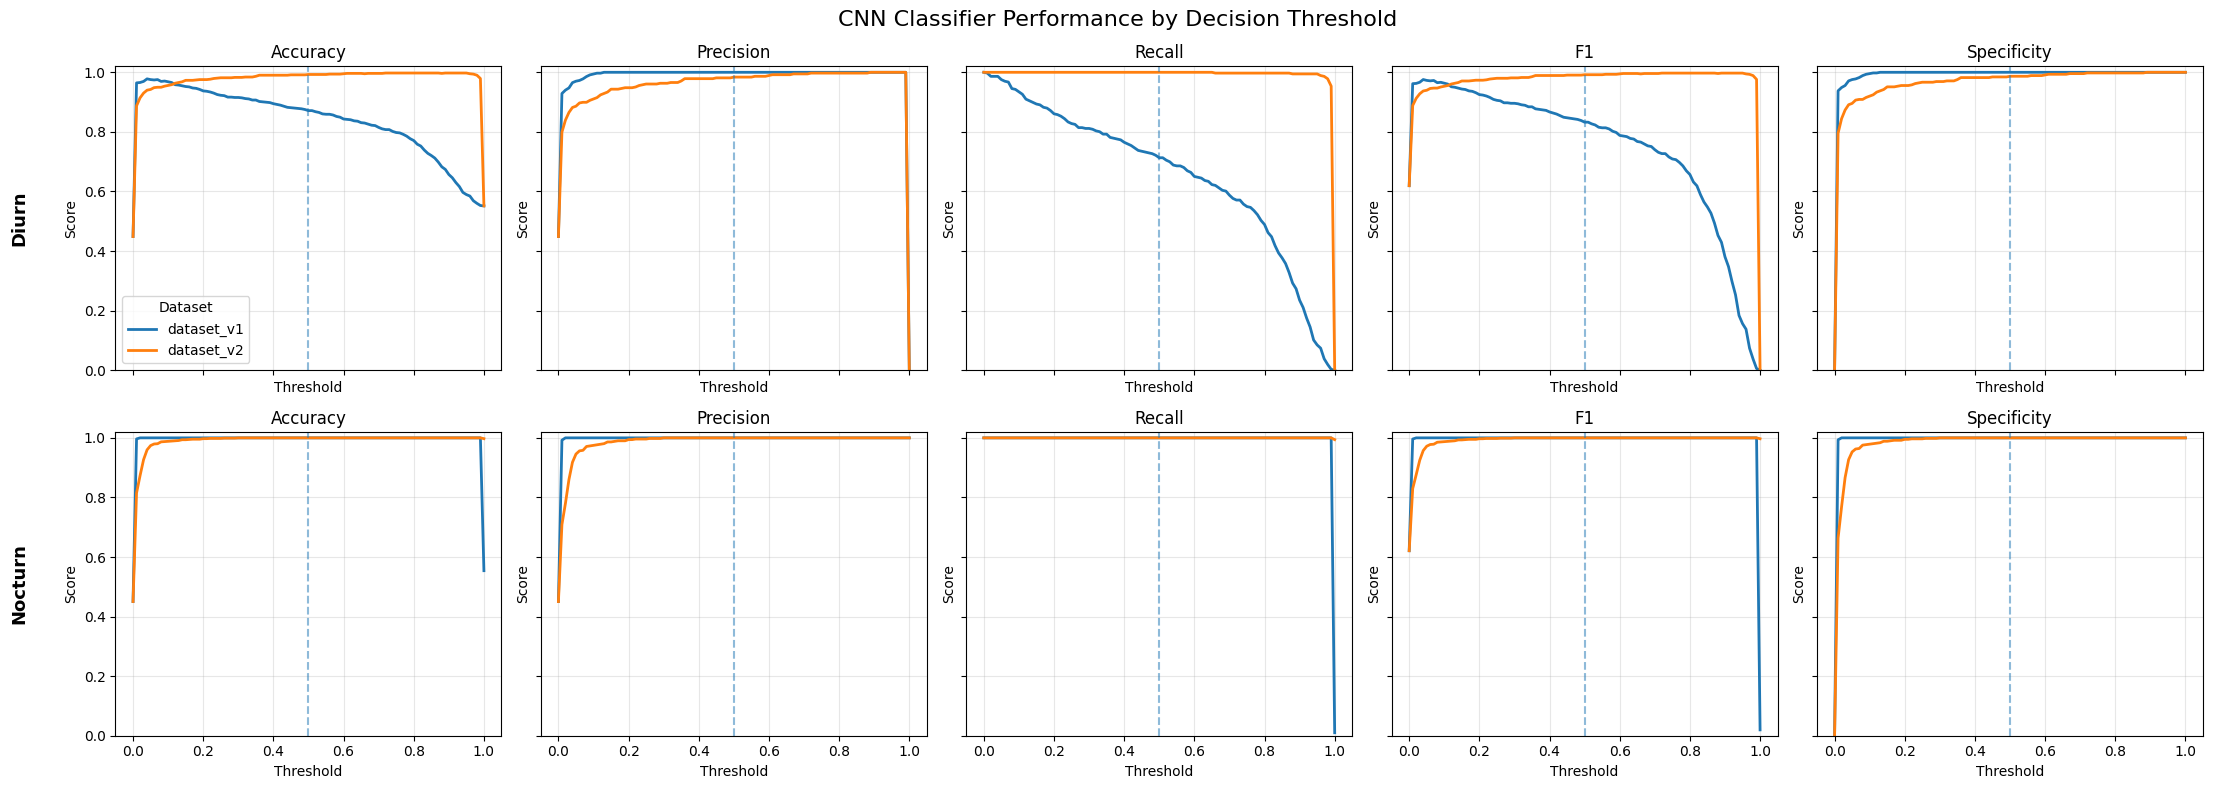

In [19]:
# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
]

test_types = [
    "diurn",
    "nocturn",
]

datasets = sorted(
    df_threshold["dataset"].unique()
)

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 8),
    sharex=True,
    sharey=True,
)

# ============================================================
# PLOTS
# ============================================================

for row, test_type in enumerate(test_types):

    data_test = df_threshold[
        df_threshold["test_type"] == test_type
    ]

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for dataset in datasets:

            data = data_test[
                data_test["dataset"] == dataset
            ]

            ax.plot(
                data["threshold"],
                data[metric],
                label=dataset,
                linewidth=2,
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_title(
            metric.capitalize()
        )

        ax.set_xlabel(
            "Threshold"
        )

        ax.set_ylabel(
            "Score"
        )

        ax.set_ylim(
            0,
            1.02,
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        # ----------------------------------------------------
        # Threshold 0.5
        # ----------------------------------------------------

        ax.axvline(
            0.5,
            linestyle="--",
            alpha=0.5,
        )

        # ----------------------------------------------------
        # Legend
        # ----------------------------------------------------

        if row == 0 and col == 0:

            ax.legend(
                title="Dataset"
            )


# ============================================================
# ROW LABELS
# ============================================================

axes[0, 0].annotate(
    "Diurn",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    rotation=90,
    va="center",
    ha="center",
    fontsize=13,
    fontweight="bold",
)

axes[1, 0].annotate(
    "Nocturn",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    rotation=90,
    va="center",
    ha="center",
    fontsize=13,
    fontweight="bold",
)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "CNN Classifier Performance by Decision Threshold",
    fontsize=16,
)

fig.tight_layout()

plt.show()

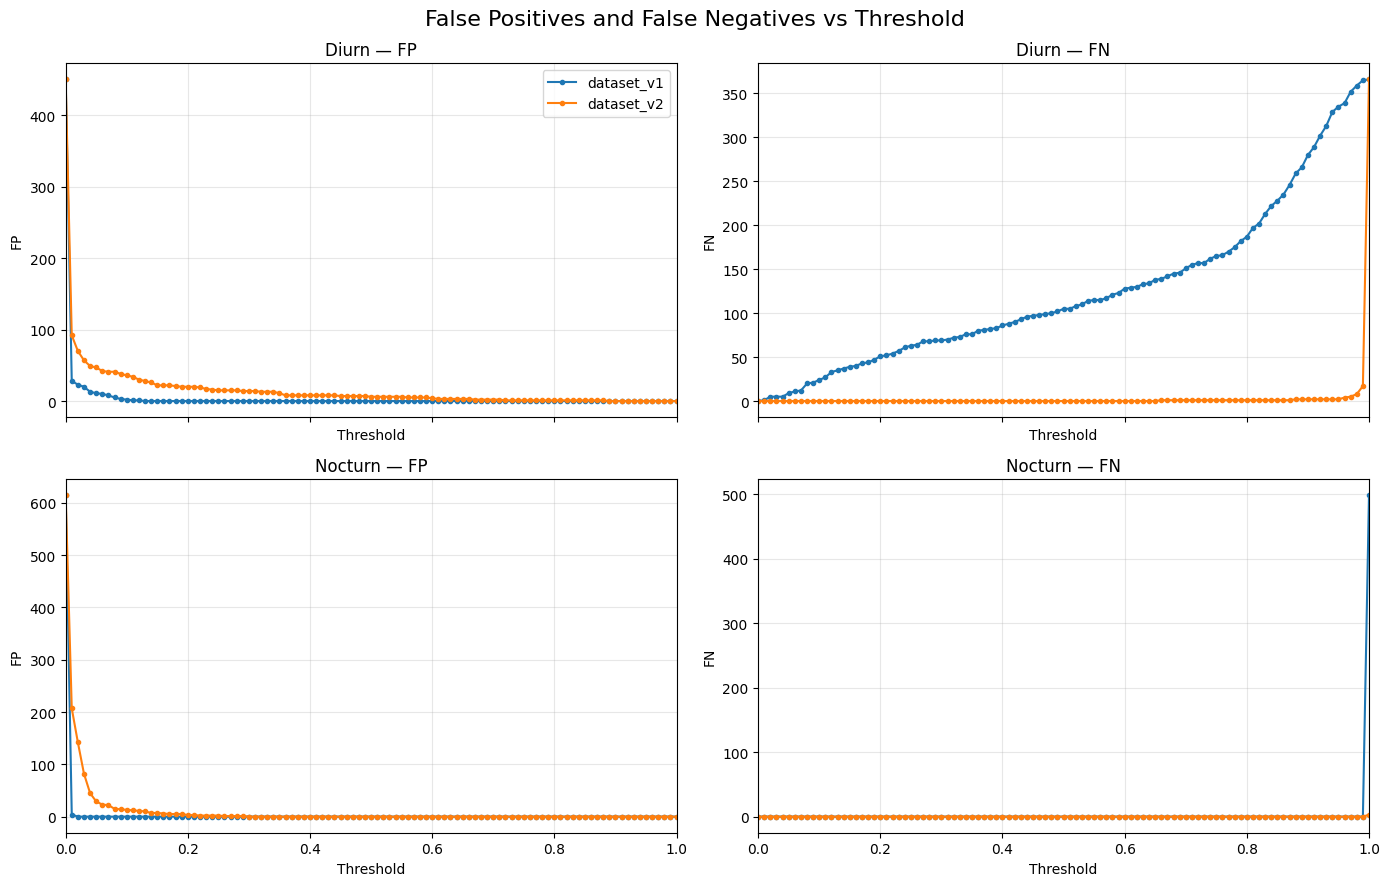

In [20]:
# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "FP",
    "FN",
]

test_types = [
    "diurn",
    "nocturn",
]

datasets = [
    "dataset_v1",
    "dataset_v2",
]


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
    sharex=True,
)

for row, test_type in enumerate(test_types):

    df_test = df_threshold[
        df_threshold["test_type"] == test_type
    ]

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for dataset in datasets:

            df_dataset = df_test[
                df_test["dataset"] == dataset
            ]

            ax.plot(
                df_dataset["threshold"],
                df_dataset[metric],
                marker="o",
                markersize=3,
                label=dataset,
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_title(
            f"{test_type.capitalize()} — {metric}"
        )

        ax.set_xlabel(
            "Threshold"
        )

        ax.set_ylabel(
            metric
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.set_xlim(
            0,
            1,
        )

        if row == 0 and col == 0:
            ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "False Positives and False Negatives vs Threshold",
    fontsize=16,
)

plt.tight_layout()

plt.show()

En el modelo entrenado con el dataset v1 se observa un marcado trade-off entre los falsos positivos y los falsos negativos. A medida que aumenta el threshold, el modelo adopta un comportamiento más conservador a la hora de clasificar un semáforo como verde, reduciendo progresivamente los falsos positivos. Sin embargo, esta mejora se produce a costa de un incremento considerable de los falsos negativos, es decir, de semáforos verdes clasificados incorrectamente como rojos.

Por el contrario, el modelo entrenado con el dataset v2 presenta un comportamiento más favorable. Para thresholds bajos, inicialmente genera un mayor número de falsos positivos, lo que implica un mayor riesgo de clasificar como verde un semáforo que realmente se encuentra en rojo. No obstante, este comportamiento se corrige rápidamente al incrementar el threshold. En un rango amplio de valores, el modelo consigue reducir progresivamente los falsos positivos manteniendo simultáneamente los falsos negativos en valores mínimos, llegando incluso a mantener un recall del 100 % en el conjunto diurno durante una amplia región de thresholds.

En el conjunto nocturno, ambos modelos presentan un comportamiento más similar. A partir de un threshold aproximado de 0.2, las diferencias entre ambos se reducen considerablemente y sus resultados tienden a converger. Por debajo de este valor se reproduce el comportamiento observado en el conjunto diurno: los thresholds bajos favorecen la aparición de un mayor número de falsos positivos, aumentando el riesgo de clasificar incorrectamente un semáforo rojo como verde.

Este comportamiento resulta especialmente relevante a la hora de evaluar el riesgo asociado a los errores de clasificación, mostrando el modelo v2 una mayor robustez, ya que permite reducir los falsos positivos sin incrementar los falsos negativos.

## Errores dataset_v1

### Diurno

In [21]:
df_v1_diurn = pd.read_csv(
    TEST_PREDICTION_PATHS["dataset_v1_diurn"]
)

df_errors_diurn = df_v1_diurn[
    df_v1_diurn["error_type"] != "correct"
].copy()

print(
    f"Diurn errors: {len(df_errors_diurn)}"
)

print(
    df_errors_diurn["error_type"].value_counts()
)

Diurn errors: 22
error_type
FP    13
FN     9
Name: count, dtype: int64


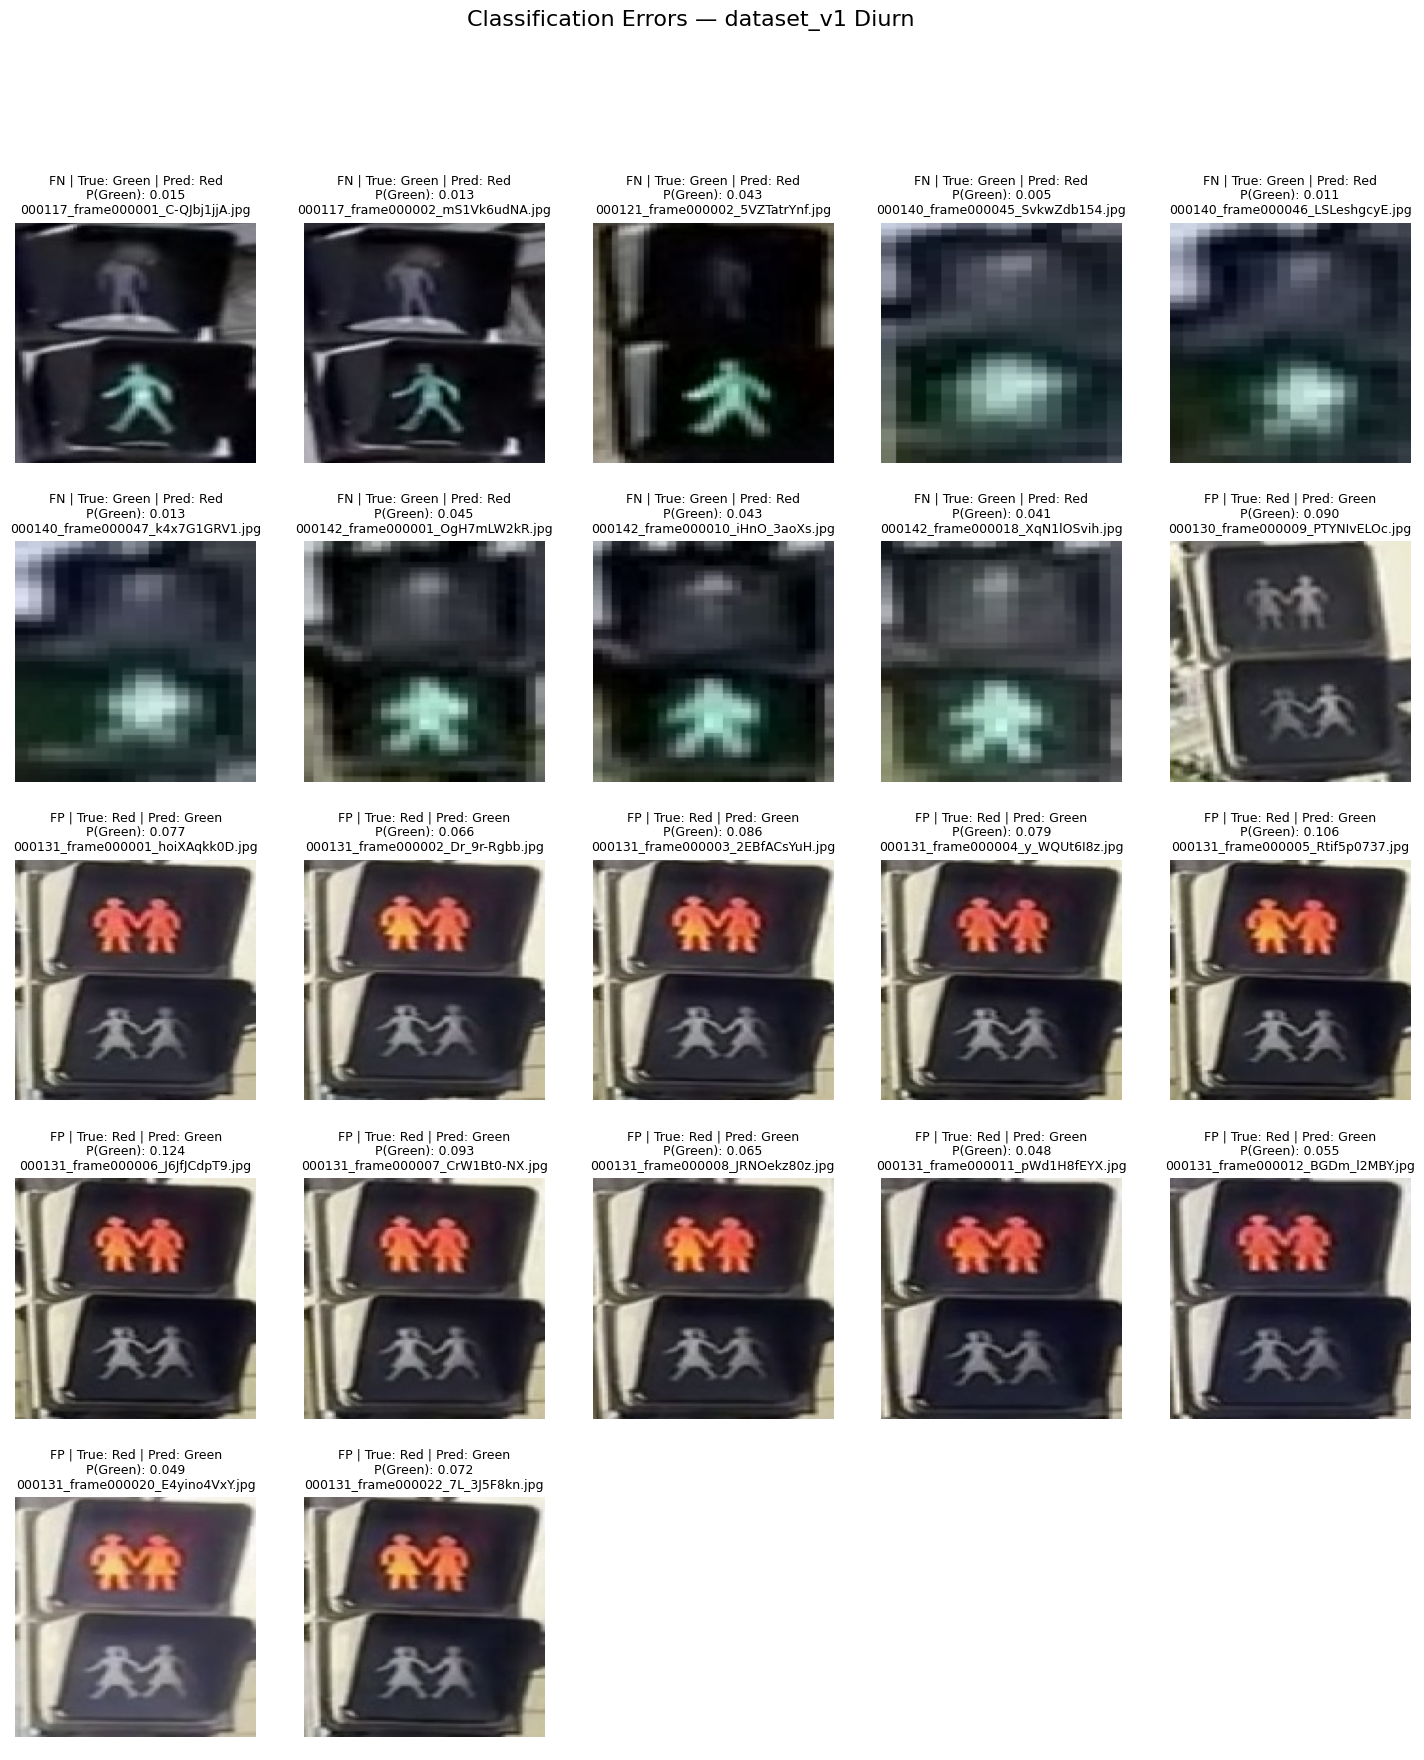

In [22]:
# ============================================================
# DIURN — PLOT ERRORS
# ============================================================

N_COLS = 5

n_images = len(df_errors_diurn)

n_rows = math.ceil(
    n_images / N_COLS
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=N_COLS,
    figsize=(18, 4 * n_rows),
)

axes = axes.flatten()


# ============================================================
# PLOT
# ============================================================

for ax, (_, row) in zip(
    axes,
    df_errors_diurn.iterrows(),
):

    image = Image.open(
        row["filepath"]
    )

    ax.imshow(
        image
    )

    ax.set_title(
        f"{row['error_type']} | "
        f"True: {row['true_class']} | "
        f"Pred: {row['predicted_class']}\n"
        f"P(Green): {row['probability_green']:.3f}\n"
        f"{row['filename']}",
        fontsize=9,
    )

    ax.axis(
        "off"
    )


# ============================================================
# HIDE UNUSED AXES
# ============================================================

for ax in axes[n_images:]:
    ax.axis(
        "off"
    )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Classification Errors — dataset_v1 Diurn",
    fontsize=16,
)


# ============================================================
# LAYOUT
# ============================================================


plt.show()

### Nocturn

In [23]:
# ============================================================
# NOCTURN — FILTER ERRORS
# ============================================================

df_v1_nocturn = pd.read_csv(
    TEST_PREDICTION_PATHS["dataset_v1_nocturn"]
)

df_errors_nocturn = df_v1_nocturn[
    df_v1_nocturn["error_type"] != "correct"
].copy()

print(
    f"Nocturn errors: {len(df_errors_nocturn)}"
)

print(
    df_errors_nocturn["error_type"].value_counts()
)

Nocturn errors: 0
Series([], Name: count, dtype: int64)


In [24]:
# # ============================================================
# # NOCTURN — PLOT ERRORS
# # ============================================================

# N_COLS = 5

# n_images = len(df_errors_nocturn)

# n_rows = math.ceil(
#     n_images / N_COLS
# )


# # ============================================================
# # FIGURE
# # ============================================================

# fig, axes = plt.subplots(
#     nrows=n_rows,
#     ncols=N_COLS,
#     figsize=(18, 4 * n_rows),
# )

# axes = axes.flatten()


# # ============================================================
# # PLOT
# # ============================================================

# for ax, (_, row) in zip(
#     axes,
#     df_errors_nocturn.iterrows(),
# ):

#     image = Image.open(
#         row["filepath"]
#     )

#     ax.imshow(
#         image
#     )

#     ax.set_title(
#         f"{row['error_type']} | "
#         f"True: {row['true_class']} | "
#         f"Pred: {row['predicted_class']}\n"
#         f"P(Green): {row['probability_green']:.3f}\n"
#         f"{row['filename']}",
#         fontsize=9,
#     )

#     ax.axis(
#         "off"
#     )


# # ============================================================
# # HIDE UNUSED AXES
# # ============================================================

# for ax in axes[n_images:]:
#     ax.axis(
#         "off"
#     )


# # ============================================================
# # TITLE
# # ============================================================

# fig.suptitle(
#     "Classification Errors — dataset_v1 Nocturn",
#     fontsize=16,
# )


# # ============================================================
# # LAYOUT
# # ============================================================


# plt.show()

## Errores dataset_v2

### Diurn

In [25]:
df_v2_diurn = pd.read_csv(
    TEST_PREDICTION_PATHS["dataset_v2_diurn"]
)

df_errors_diurn = df_v2_diurn[
    df_v2_diurn["error_type"] != "correct"
].copy()

print(
    f"Diurn errors: {len(df_errors_diurn)}"
)

print(
    df_errors_diurn["error_type"].value_counts()
)

Diurn errors: 2
error_type
FN    1
FP    1
Name: count, dtype: int64


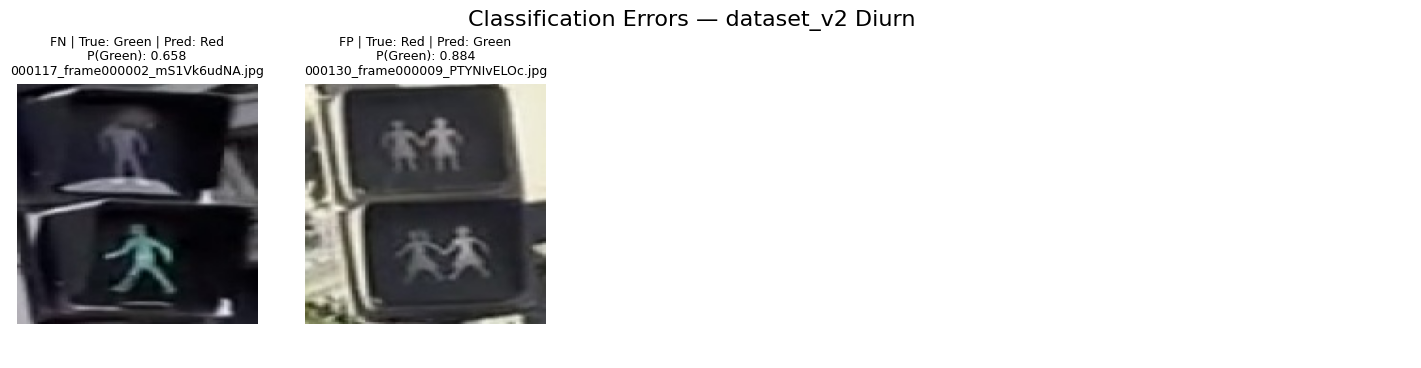

In [26]:
# ============================================================
# DIURN — PLOT ERRORS
# ============================================================

N_COLS = 5

n_images = len(df_errors_diurn)

n_rows = math.ceil(
    n_images / N_COLS
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=N_COLS,
    figsize=(18, 4 * n_rows),
)

axes = axes.flatten()


# ============================================================
# PLOT
# ============================================================

for ax, (_, row) in zip(
    axes,
    df_errors_diurn.iterrows(),
):

    image = Image.open(
        row["filepath"]
    )

    ax.imshow(
        image
    )

    ax.set_title(
        f"{row['error_type']} | "
        f"True: {row['true_class']} | "
        f"Pred: {row['predicted_class']}\n"
        f"P(Green): {row['probability_green']:.3f}\n"
        f"{row['filename']}",
        fontsize=9,
    )

    ax.axis(
        "off"
    )


# ============================================================
# HIDE UNUSED AXES
# ============================================================

for ax in axes[n_images:]:
    ax.axis(
        "off"
    )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Classification Errors — dataset_v2 Diurn",
    fontsize=16,
)


# ============================================================
# LAYOUT
# ============================================================


plt.show()

### Nocturn

In [27]:
# ============================================================
# NOCTURN — FILTER ERRORS
# ============================================================

df_v2_nocturn = pd.read_csv(
    TEST_PREDICTION_PATHS["dataset_v2_nocturn"]
)

df_errors_nocturn = df_v2_nocturn[
    df_v2_nocturn["error_type"] != "correct"
].copy()

print(
    f"Nocturn errors: {len(df_errors_nocturn)}"
)

print(
    df_errors_nocturn["error_type"].value_counts()
)

Nocturn errors: 0
Series([], Name: count, dtype: int64)


In [28]:
# # ============================================================
# # NOCTURN — PLOT ERRORS
# # ============================================================

# N_COLS = 5

# n_images = len(df_errors_nocturn)

# n_rows = math.ceil(
#     n_images / N_COLS
# )


# # ============================================================
# # FIGURE
# # ============================================================

# fig, axes = plt.subplots(
#     nrows=n_rows,
#     ncols=N_COLS,
#     figsize=(18, 4 * n_rows),
# )

# axes = axes.flatten()


# # ============================================================
# # PLOT
# # ============================================================

# for ax, (_, row) in zip(
#     axes,
#     df_errors_nocturn.iterrows(),
# ):

#     image = Image.open(
#         row["filepath"]
#     )

#     ax.imshow(
#         image
#     )

#     ax.set_title(
#         f"{row['error_type']} | "
#         f"True: {row['true_class']} | "
#         f"Pred: {row['predicted_class']}\n"
#         f"P(Green): {row['probability_green']:.3f}\n"
#         f"{row['filename']}",
#         fontsize=9,
#     )

#     ax.axis(
#         "off"
#     )


# # ============================================================
# # HIDE UNUSED AXES
# # ============================================================

# for ax in axes[n_images:]:
#     ax.axis(
#         "off"
#     )


# # ============================================================
# # TITLE
# # ============================================================

# fig.suptitle(
#     "Classification Errors — dataset_v1 Nocturn",
#     fontsize=16,
# )


# # ============================================================
# # LAYOUT
# # ============================================================


# plt.show()

## Análisis de distribuciones por clase

V1 Diurn
Total errors: 22

Error types:
error_type
FP    13
FN     9
Name: count, dtype: int64

Probability statistics:
count    22.000000
mean      0.056283
std       0.032963
min       0.005271
25%       0.041237
50%       0.051811
75%       0.078327
max       0.124111
Name: probability_green, dtype: float64

Distance to threshold:
count    22.000000
mean      0.443717
std       0.032963
min       0.375889
25%       0.421673
50%       0.448189
75%       0.458763
max       0.494729
Name: distance_to_threshold, dtype: float64

V2 Diurn
Total errors: 2

Error types:
error_type
FN    1
FP    1
Name: count, dtype: int64

Probability statistics:
count    2.000000
mean     0.771341
std      0.159839
min      0.658317
25%      0.714829
50%      0.771341
75%      0.827852
max      0.884364
Name: probability_green, dtype: float64

Distance to threshold:
count    2.000000
mean     0.271341
std      0.159839
min      0.158317
25%      0.214829
50%      0.271341
75%      0.327852
max      0.38436

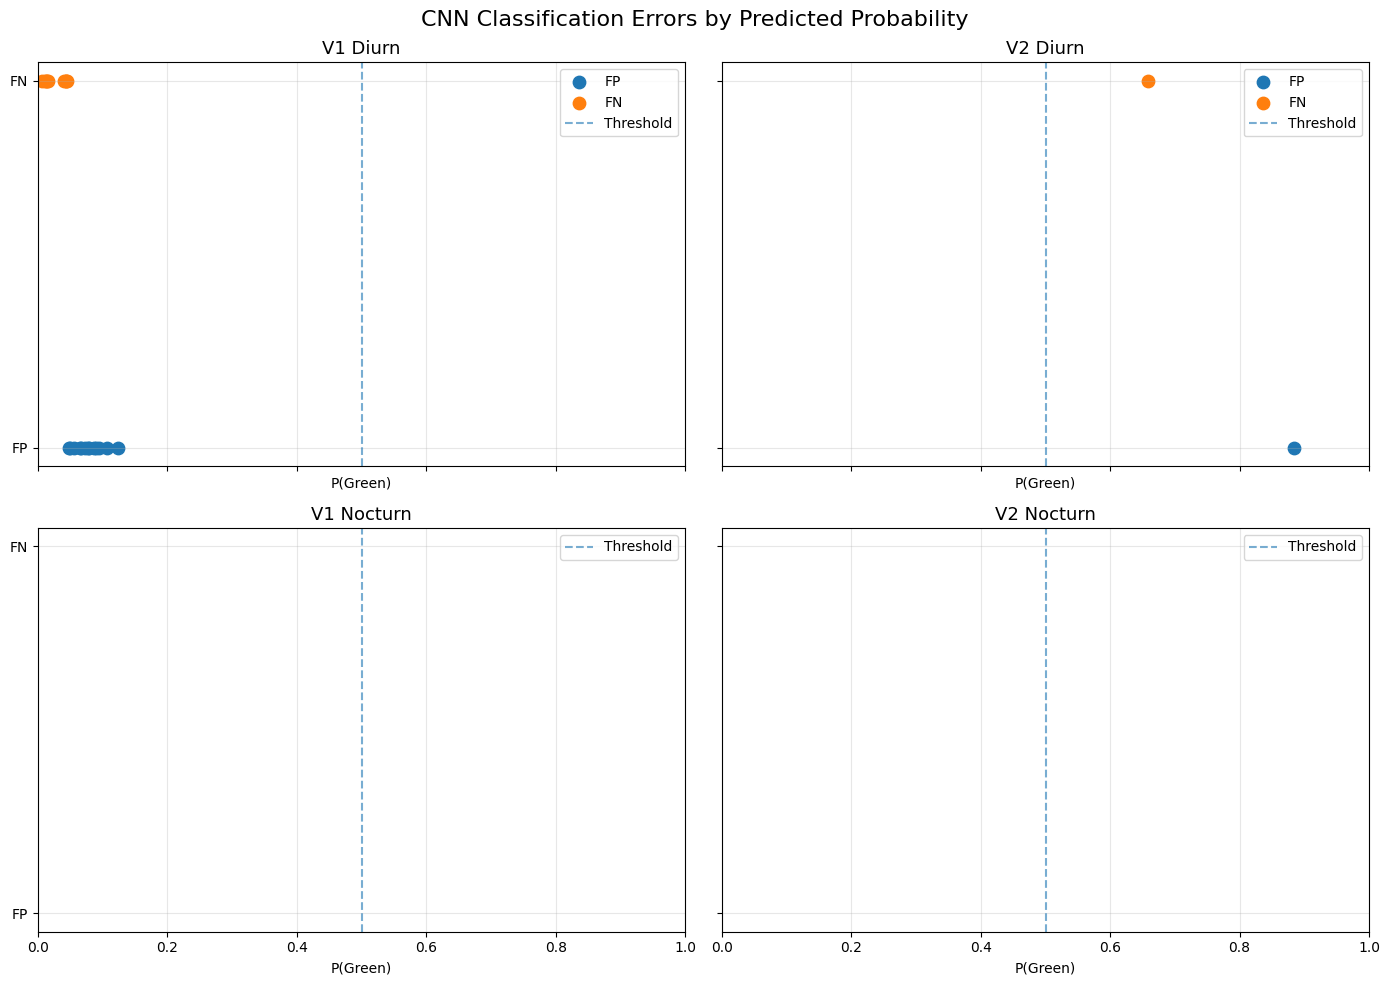

In [29]:
# ============================================================
# CONFIGURATION
# ============================================================

datasets = {
    "V1 Diurn": df_v1_diurn,
    "V2 Diurn": df_v2_diurn,
    "V1 Nocturn": df_v1_nocturn,
    "V2 Nocturn": df_v2_nocturn,
}

THRESHOLD = 0.5


# ============================================================
# PREPARE ERRORS
# ============================================================

error_dfs = {}

for name, df in datasets.items():

    errors = df[
        df["error_type"] != "correct"
    ].copy()

    errors["distance_to_threshold"] = (
        errors["probability_green"] - THRESHOLD
    ).abs()

    error_dfs[name] = errors


# ============================================================
# SUMMARY
# ============================================================

for name, df_errors in error_dfs.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        f"Total errors: {len(df_errors)}"
    )

    if len(df_errors) == 0:
        print()
        continue

    print(
        "\nError types:"
    )

    print(
        df_errors["error_type"].value_counts()
    )

    print(
        "\nProbability statistics:"
    )

    print(
        df_errors["probability_green"].describe()
    )

    print(
        "\nDistance to threshold:"
    )

    print(
        df_errors["distance_to_threshold"].describe()
    )

    print()


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()


for ax, (name, df_errors) in zip(
    axes,
    error_dfs.items(),
):

    # --------------------------------------------------------
    # FP
    # --------------------------------------------------------

    fp = df_errors[
        df_errors["error_type"] == "FP"
    ]

    # --------------------------------------------------------
    # FN
    # --------------------------------------------------------

    fn = df_errors[
        df_errors["error_type"] == "FN"
    ]

    # --------------------------------------------------------
    # Plot FP
    # --------------------------------------------------------

    if len(fp) > 0:

        ax.scatter(
            fp["probability_green"],
            [0] * len(fp),
            label="FP",
            s=80,
        )

    # --------------------------------------------------------
    # Plot FN
    # --------------------------------------------------------

    if len(fn) > 0:

        ax.scatter(
            fn["probability_green"],
            [1] * len(fn),
            label="FN",
            s=80,
        )

    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    ax.axvline(
        THRESHOLD,
        linestyle="--",
        alpha=0.6,
        label="Threshold",
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        name,
        fontsize=13,
    )

    ax.set_xlabel(
        "P(Green)"
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_yticklabels(
        ["FP", "FN"]
    )

    ax.set_xlim(
        0,
        1,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "CNN Classification Errors by Predicted Probability",
    fontsize=16,
)

plt.tight_layout()

plt.show()

V1 common Youden threshold: 0.0408
V2 common Youden threshold: 0.8768


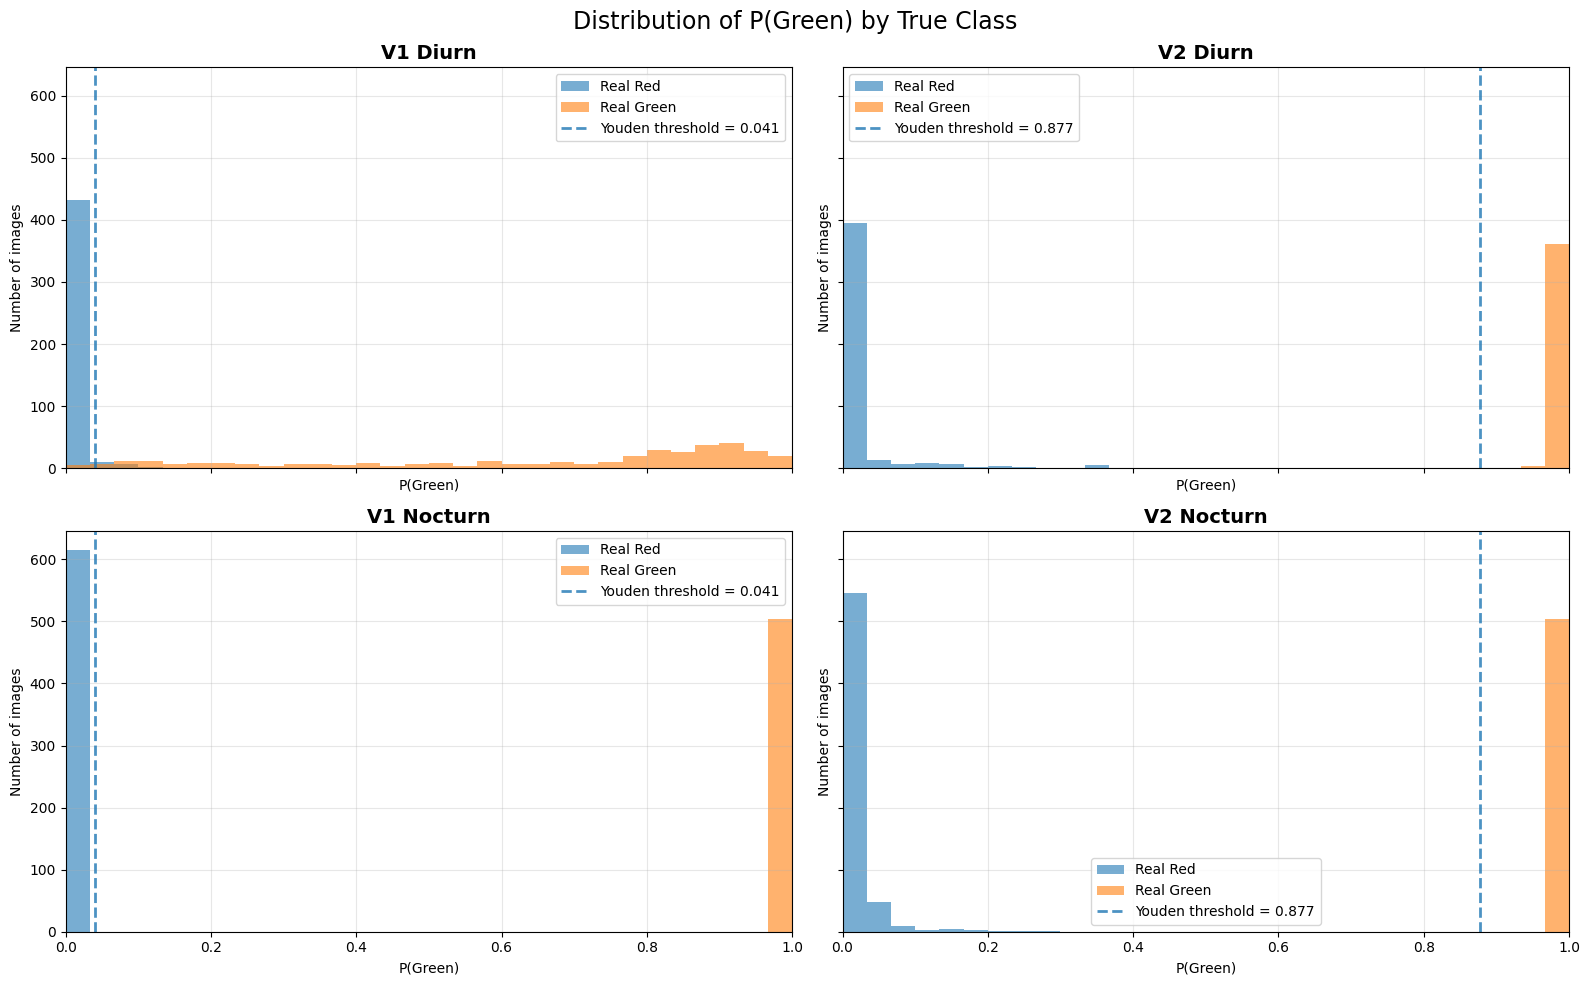

In [30]:
# ============================================================
# CONFIGURATION
# ============================================================

datasets = {
    "V1 Diurn": df_v1_diurn,
    "V2 Diurn": df_v2_diurn,
    "V1 Nocturn": df_v1_nocturn,
    "V2 Nocturn": df_v2_nocturn,
}


# ============================================================
# CALCULATE COMMON YOUDEN THRESHOLD
#
# Un único threshold por modelo utilizando conjuntamente
# los datos diurnos y nocturnos.
# ============================================================

thresholds = {}


for version in ["V1", "V2"]:

    if version == "V1":

        df_combined = pd.concat(
            [
                df_v1_diurn,
                df_v1_nocturn,
            ],
            ignore_index=True,
        )

    else:

        df_combined = pd.concat(
            [
                df_v2_diurn,
                df_v2_nocturn,
            ],
            ignore_index=True,
        )

    # --------------------------------------------------------
    # True labels
    #
    # Red   -> 0
    # Green -> 1
    # --------------------------------------------------------

    y_true = (
        df_combined["true_label"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # Model output
    #
    # P(Green)
    # --------------------------------------------------------

    y_scores = (
        df_combined["probability_green"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # ROC
    # --------------------------------------------------------

    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_scores,
    )

    # --------------------------------------------------------
    # Remove infinite threshold
    # --------------------------------------------------------

    valid = np.isfinite(
        roc_thresholds
    )

    fpr = fpr[valid]
    tpr = tpr[valid]
    roc_thresholds = roc_thresholds[valid]

    # --------------------------------------------------------
    # Youden's J
    #
    # J = TPR - FPR
    # --------------------------------------------------------

    youden = (
        tpr - fpr
    )

    best_index = np.argmax(
        youden
    )

    best_threshold = float(
        roc_thresholds[best_index]
    )

    thresholds[version] = (
        best_threshold
    )

    print(
        f"{version} common Youden threshold: "
        f"{best_threshold:.4f}"
    )


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
    sharex=True,
    sharey=True,
)


# ============================================================
# PLOTS
# ============================================================

for ax, (name, df) in zip(
    axes.flatten(),
    datasets.items(),
):

    # --------------------------------------------------------
    # Dataset version
    # --------------------------------------------------------

    version = name.split()[0]

    threshold = thresholds[
        version
    ]

    # --------------------------------------------------------
    # Real Red
    # --------------------------------------------------------

    red = df.loc[
        df["true_class"] == "Red",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Real Green
    # --------------------------------------------------------

    green = df.loc[
        df["true_class"] == "Green",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Histograms
    # --------------------------------------------------------

    ax.hist(
        red,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Red",
    )

    ax.hist(
        green,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Green",
    )

    # --------------------------------------------------------
    # Common Youden threshold
    # --------------------------------------------------------

    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=(
            f"Youden threshold = "
            f"{threshold:.3f}"
        ),
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        name,
        fontsize=14,
        fontweight="bold",
    )

    ax.set_xlabel(
        "P(Green)"
    )

    ax.set_ylabel(
        "Number of images"
    )

    ax.set_xlim(
        0,
        1,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Distribution of P(Green) by True Class",
    fontsize=17,
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

plt.show()

Se observa que las probabilidades predichas por los modelos siguen distribuciones completamente diferentes. Para el primero, tenemos rojos con probabilidades de verde muy bajos mientras que las probabilidades de los verdes están mucho más dispersas. Existen, de hecho, solapamientos en probabilidades bajas.

Sin embargo, para el v2, las probabilidades de rojos y verdes están mucho más separadas. Si el semáforo es rojo, P(verde) tiende a valores muy bajos mientras que si el semáforo es verde, P(verde) tiende a ser muy alto.

De noche parece que estas diferencias están más marcadas en v1 pero también son excelentes en v2.

Lo más importante para comparar los modelos es que requieren puntos de threshold completamente diferentes ya que sus puntos de Youden son muy distintos.

# Interpretabilidad del modelo en Validación

Se decide, por lo anterior mencionado, coger el modelo v2.

In [31]:
# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_SIZE = (
    128,
    128,
)

THRESHOLD_V2 = 0.8

N_PER_CLASS = 3

In [32]:
# ============================================================
# LOAD MODEL
# ============================================================

model = tf.keras.models.load_model(
    MODEL_PATH
)


# ============================================================
# CONVOLUTIONAL LAYERS
# ============================================================

conv_layers = [
    layer.name
    for layer in model.layers
    if isinstance(
        layer,
        tf.keras.layers.Conv2D,
    )
]

print(
    "Convolutional layers:"
)

for layer_name in conv_layers:

    print(
        f"  {layer_name}"
    )


# ============================================================
# LAST CONVOLUTIONAL LAYER
# ============================================================

PENULTIMATE_LAYER = conv_layers[
    -1
]

print()
print(
    f"Grad-CAM layer: "
    f"{PENULTIMATE_LAYER}"
)

Convolutional layers:
  conv_1
  conv_2
  conv_3
  conv_4
  conv_5
  conv_6
  conv_7
  conv_8

Grad-CAM layer: conv_8


In [33]:
# ============================================================
# PREPARE V2 PREDICTIONS
# ============================================================

df_gradcam = df_v2.copy()


# ============================================================
# RECALCULATE PREDICTIONS WITH FINAL THRESHOLD
#
# 0 -> Red
# 1 -> Green
# ============================================================

df_gradcam[
    "gradcam_predicted_label"
] = (
    df_gradcam[
        "probability_green"
    ] >= THRESHOLD_V2
).astype(
    int
)


# ============================================================
# CORRECT PREDICTIONS
# ============================================================

df_gradcam[
    "correct"
] = (
    df_gradcam[
        "true_label"
    ]
    ==
    df_gradcam[
        "gradcam_predicted_label"
    ]
)


# ============================================================
# CORRECT RED
#
# Real Red      -> 0
# Predicted Red -> 0
# ============================================================

df_correct_red = df_gradcam[
    (
        df_gradcam[
            "true_label"
        ] == 0
    )
    &
    (
        df_gradcam[
            "correct"
        ]
    )
].copy()


# ============================================================
# CORRECT GREEN
#
# Real Green      -> 1
# Predicted Green -> 1
# ============================================================

df_correct_green = df_gradcam[
    (
        df_gradcam[
            "true_label"
        ] == 1
    )
    &
    (
        df_gradcam[
            "correct"
        ]
    )
].copy()


print(
    f"Correct Red: "
    f"{len(df_correct_red)}"
)

print(
    f"Correct Green: "
    f"{len(df_correct_green)}"
)

Correct Red: 1083
Correct Green: 818


Grad-CAM layer: conv_8
Total test images: 1935

Correct predictions:
test_type  true_class
diurn      Green         365
           Red           449
nocturn    Green         504
           Red           615
dtype: int64


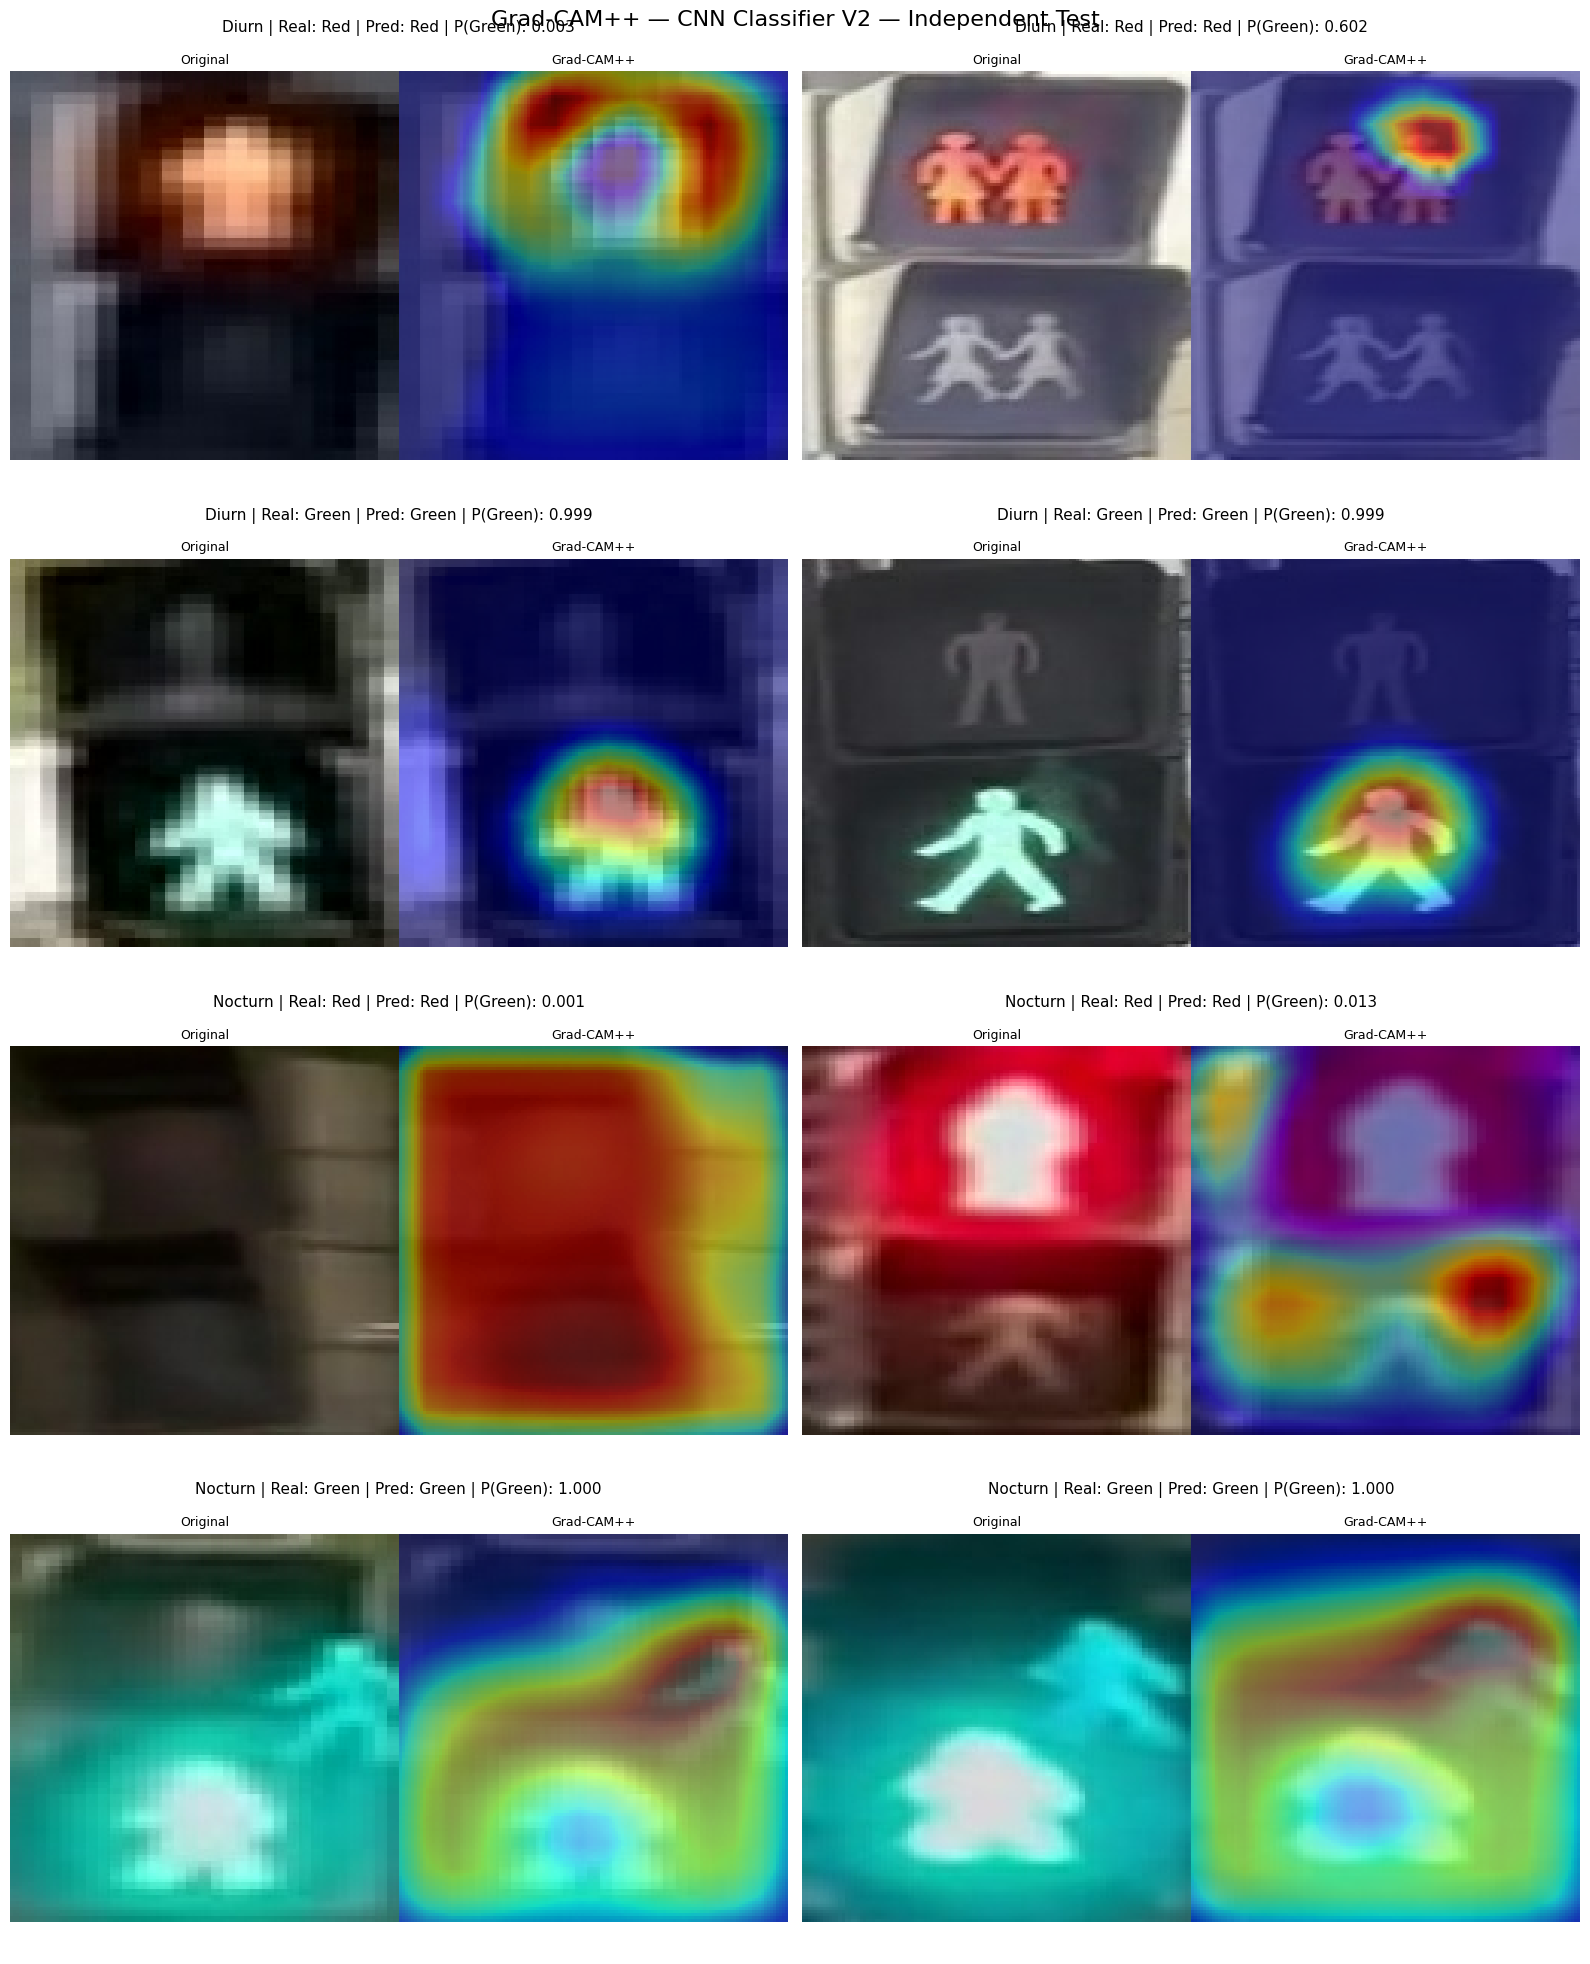

In [34]:
# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_SIZE = (
    128,
    128,
)

THRESHOLD = 0.8

# Número de imágenes por grupo:
#
# Diurn Red
# Diurn Green
# Nocturn Red
# Nocturn Green

N_PER_GROUP = 2

COLS = 2


# ============================================================
# LOAD MODEL
# ============================================================

model = tf.keras.models.load_model(
    MODEL_PATH
)


# ============================================================
# LAST CONVOLUTIONAL LAYER
# ============================================================

conv_layers = [
    layer.name
    for layer in model.layers
    if isinstance(
        layer,
        tf.keras.layers.Conv2D,
    )
]

PENULTIMATE_LAYER = conv_layers[-1]

print(
    f"Grad-CAM layer: "
    f"{PENULTIMATE_LAYER}"
)


# ============================================================
# LOAD TEST IMAGE PATHS
#
# Convention:
#
# 0 -> Red
# 1 -> Green
# ============================================================

rows = []

for test_type in [
    "diurn",
    "nocturn",
]:

    for class_name, true_label in [
        ("Red", 0),
        ("Green", 1),
    ]:

        class_dir = (
            CLASSIFIER_TEST_DIR
            / test_type
            / class_name
        )

        for image_path in class_dir.iterdir():

            if image_path.suffix.lower() in [
                ".jpg",
                ".jpeg",
                ".png",
            ]:

                rows.append({
                    "filepath": image_path,
                    "filename": image_path.name,
                    "test_type": test_type,
                    "true_class": class_name,
                    "true_label": true_label,
                })


df_test_gradcam = pd.DataFrame(
    rows
)

print(
    f"Total test images: "
    f"{len(df_test_gradcam)}"
)


# ============================================================
# PREDICTIONS
# ============================================================

probabilities = []

for image_path in df_test_gradcam[
    "filepath"
]:

    # Misma carga que image_dataset_from_directory() en las métricas.
    image = tf.io.decode_image(
        tf.io.read_file(str(image_path)),
        channels=3,
        expand_animations=False,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear",
    ).numpy()

    image_input = tf.expand_dims(
        image,
        axis=0,
    )

    probability_green = model.predict(
        image_input,
        verbose=0,
    )[0][0]

    probabilities.append(
        float(
            probability_green
        )
    )


df_test_gradcam[
    "probability_green"
] = probabilities


# ============================================================
# CLASSIFICATION WITH FINAL THRESHOLD
#
# probability >= 0.8 -> Green
# probability <  0.8 -> Red
# ============================================================

df_test_gradcam[
    "pred_label"
] = (
    df_test_gradcam[
        "probability_green"
    ] >= THRESHOLD
).astype(
    int
)


df_test_gradcam[
    "pred_class"
] = np.where(
    df_test_gradcam[
        "pred_label"
    ] == 1,
    "Green",
    "Red",
)


# ============================================================
# KEEP ONLY CORRECT PREDICTIONS
# ============================================================

df_correct = df_test_gradcam[
    df_test_gradcam[
        "true_label"
    ]
    ==
    df_test_gradcam[
        "pred_label"
    ]
].copy()


print()
print(
    "Correct predictions:"
)

print(
    df_correct.groupby(
        [
            "test_type",
            "true_class",
        ]
    ).size()
)


# ============================================================
# SAMPLE EACH GROUP
# ============================================================

samples = []

for test_type in [
    "diurn",
    "nocturn",
]:

    for class_name in [
        "Red",
        "Green",
    ]:

        group = df_correct[
            (
                df_correct[
                    "test_type"
                ] == test_type
            )
            &
            (
                df_correct[
                    "true_class"
                ] == class_name
            )
        ]

        group_sample = group.sample(
            n=min(
                N_PER_GROUP,
                len(group),
            ),
            random_state=42,
        )

        samples.append(
            group_sample
        )


df_samples = pd.concat(
    samples,
    ignore_index=True,
)


# ============================================================
# GRAD-CAM++
# ============================================================

gradcam = GradcamPlusPlus(
    model=model,
    model_modifier=ReplaceToLinear(),
    clone=True,
)


# ============================================================
# FIGURE
# ============================================================

N_IMAGES = len(
    df_samples
)

ROWS = int(
    np.ceil(
        N_IMAGES / COLS
    )
)

fig = plt.figure(
    figsize=(
        8 * COLS,
        5 * ROWS,
    )
)


# ============================================================
# PLOTS
# ============================================================

for i, (_, row) in enumerate(
    df_samples.iterrows()
):

    # Misma carga que image_dataset_from_directory() en las métricas.
    image = tf.io.decode_image(
        tf.io.read_file(str(row["filepath"])),
        channels=3,
        expand_animations=False,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear",
    ).numpy()

    image_input = tf.expand_dims(
        image,
        axis=0,
    )

    pred_label = int(
        row["pred_label"]
    )

    probability_green = float(
        row["probability_green"]
    )


    # --------------------------------------------------------
    # Grad-CAM++
    # --------------------------------------------------------

    cam = gradcam(
        BinaryScore(
            bool(
                pred_label
            )
        ),
        image_input,
        penultimate_layer=PENULTIMATE_LAYER,
    )


    # --------------------------------------------------------
    # Image
    # --------------------------------------------------------

    img = image.astype(
        np.uint8
    )


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    heatmap = np.uint8(
        cm.jet(
            cam[0]
        )[..., :3]
        * 255
    )


    # --------------------------------------------------------
    # Plot cell
    # --------------------------------------------------------

    outer = fig.add_subplot(
        ROWS,
        COLS,
        i + 1,
    )

    outer.axis(
        "off"
    )

    outer.set_title(
        f"{row['test_type'].capitalize()} | "
        f"Real: {row['true_class']} | "
        f"Pred: {row['pred_class']} | "
        f"P(Green): {probability_green:.3f}",
        fontsize=11,
    )


    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    left = outer.inset_axes(
        [
            0,
            0,
            0.5,
            1,
        ]
    )

    left.imshow(
        img
    )

    left.axis(
        "off"
    )

    left.set_title(
        "Original",
        fontsize=9,
    )


    # --------------------------------------------------------
    # Grad-CAM++
    # --------------------------------------------------------

    right = outer.inset_axes(
        [
            0.5,
            0,
            0.5,
            1,
        ]
    )

    right.imshow(
        img
    )

    right.imshow(
        heatmap,
        alpha=0.5,
    )

    right.axis(
        "off"
    )

    right.set_title(
        "Grad-CAM++",
        fontsize=9,
    )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Grad-CAM++ — CNN Classifier V2 — Independent Test",
    fontsize=16,
)

plt.tight_layout()

plt.show()

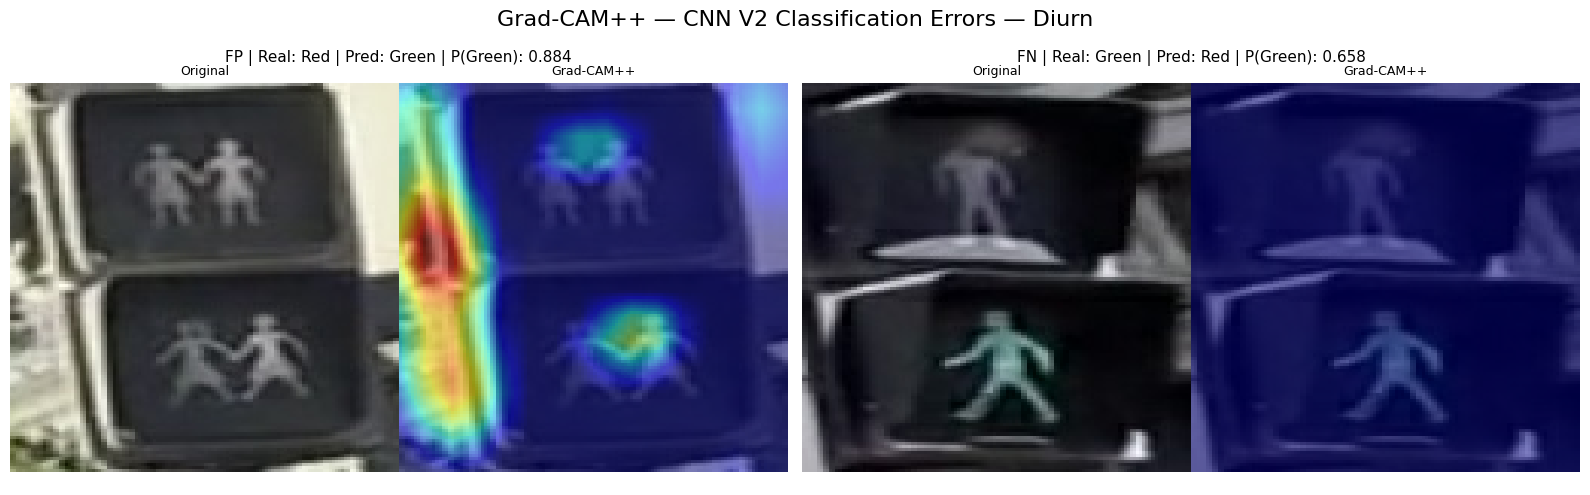

In [35]:
# ============================================================
# CLASSIFICATION ERRORS — GRAD-CAM++
# ============================================================

df_errors = df_test_gradcam[
    df_test_gradcam["true_label"]
    !=
    df_test_gradcam["pred_label"]
].copy()


# ============================================================
# PLOT ERRORS BY TEST TYPE
# ============================================================

for test_type in [
    "diurn",
    "nocturn",
]:

    errors = df_errors[
        df_errors["test_type"] == test_type
    ].copy()

    # Si no existen errores, no mostrar nada
    if len(errors) == 0:
        continue


    # ========================================================
    # FIGURE
    # ========================================================

    COLS = 2

    N_IMAGES = len(
        errors
    )

    ROWS = int(
        np.ceil(
            N_IMAGES / COLS
        )
    )

    fig = plt.figure(
        figsize=(
            8 * COLS,
            5 * ROWS,
        )
    )


    # ========================================================
    # PLOTS
    # ========================================================

    for i, (_, row) in enumerate(
        errors.iterrows()
    ):

        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        # Misma carga que image_dataset_from_directory() en las métricas.
        image = tf.io.decode_image(
            tf.io.read_file(str(row["filepath"])),
            channels=3,
            expand_animations=False,
        )

        image = tf.image.resize(
            image,
            IMAGE_SIZE,
            method="bilinear",
        ).numpy()

        image_input = tf.expand_dims(
            image,
            axis=0,
        )


        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        true_label = int(
            row["true_label"]
        )

        pred_label = int(
            row["pred_label"]
        )

        probability_green = float(
            row["probability_green"]
        )


        # ----------------------------------------------------
        # Error type
        #
        # FP -> Red real / Green predicho
        # FN -> Green real / Red predicho
        # ----------------------------------------------------

        if (
            true_label == 0
            and pred_label == 1
        ):

            error_type = "FP"

        else:

            error_type = "FN"


        # ----------------------------------------------------
        # Grad-CAM++
        #
        # Explicamos la clase que el modelo ha predicho.
        # ----------------------------------------------------

        cam = gradcam(
            BinaryScore(
                bool(
                    pred_label
                )
            ),
            image_input,
            penultimate_layer=PENULTIMATE_LAYER,
        )


        # ----------------------------------------------------
        # Image
        # ----------------------------------------------------

        img = image.astype(
            np.uint8
        )


        # ----------------------------------------------------
        # Heatmap
        # ----------------------------------------------------

        heatmap = np.uint8(
            cm.jet(
                cam[0]
            )[..., :3]
            * 255
        )


        # ====================================================
        # CELL
        # ====================================================

        outer = fig.add_subplot(
            ROWS,
            COLS,
            i + 1,
        )

        outer.axis(
            "off"
        )

        outer.set_title(
            f"{error_type} | "
            f"Real: {row['true_class']} | "
            f"Pred: {row['pred_class']} | "
            f"P(Green): {probability_green:.3f}",
            fontsize=11,
        )


        # ----------------------------------------------------
        # Original
        # ----------------------------------------------------

        left = outer.inset_axes(
            [
                0,
                0,
                0.5,
                1,
            ]
        )

        left.imshow(
            img
        )

        left.axis(
            "off"
        )

        left.set_title(
            "Original",
            fontsize=9,
        )


        # ----------------------------------------------------
        # Grad-CAM++
        # ----------------------------------------------------

        right = outer.inset_axes(
            [
                0.5,
                0,
                0.5,
                1,
            ]
        )

        right.imshow(
            img
        )

        right.imshow(
            heatmap,
            alpha=0.5,
        )

        right.axis(
            "off"
        )

        right.set_title(
            "Grad-CAM++",
            fontsize=9,
        )


    # ========================================================
    # TITLE
    # ========================================================

    fig.suptitle(
        f"Grad-CAM++ — CNN V2 Classification Errors — "
        f"{test_type.capitalize()}",
        fontsize=16,
    )

    plt.tight_layout()

    plt.show()

Grad-CAM layer: conv_8
Diurn | Green | Original score: 0.999388 | Max drop: 0.998722 | Min drop: 0.000850 | Mean abs change: 0.563298
Diurn | Green | Original score: 0.990840 | Max drop: 0.989478 | Min drop: 0.005627 | Mean abs change: 0.718773
Diurn | Green | Original score: 0.999816 | Max drop: 0.995823 | Min drop: 0.000018 | Mean abs change: 0.437527
Diurn | Red | Original score: 0.999677 | Max drop: 0.000355 | Min drop: -0.000156 | Mean abs change: 0.000122
Diurn | Red | Original score: 0.999148 | Max drop: 0.001116 | Min drop: -0.000359 | Mean abs change: 0.000262
Diurn | Red | Original score: 0.912086 | Max drop: 0.505524 | Min drop: -0.086308 | Mean abs change: 0.106867
Nocturn | Green | Original score: 1.000000 | Max drop: 0.000000 | Min drop: 0.000000 | Mean abs change: 0.000000
Nocturn | Green | Original score: 1.000000 | Max drop: 0.000000 | Min drop: 0.000000 | Mean abs change: 0.000000
Nocturn | Green | Original score: 1.000000 | Max drop: 0.000000 | Min drop: 0.000000 | M

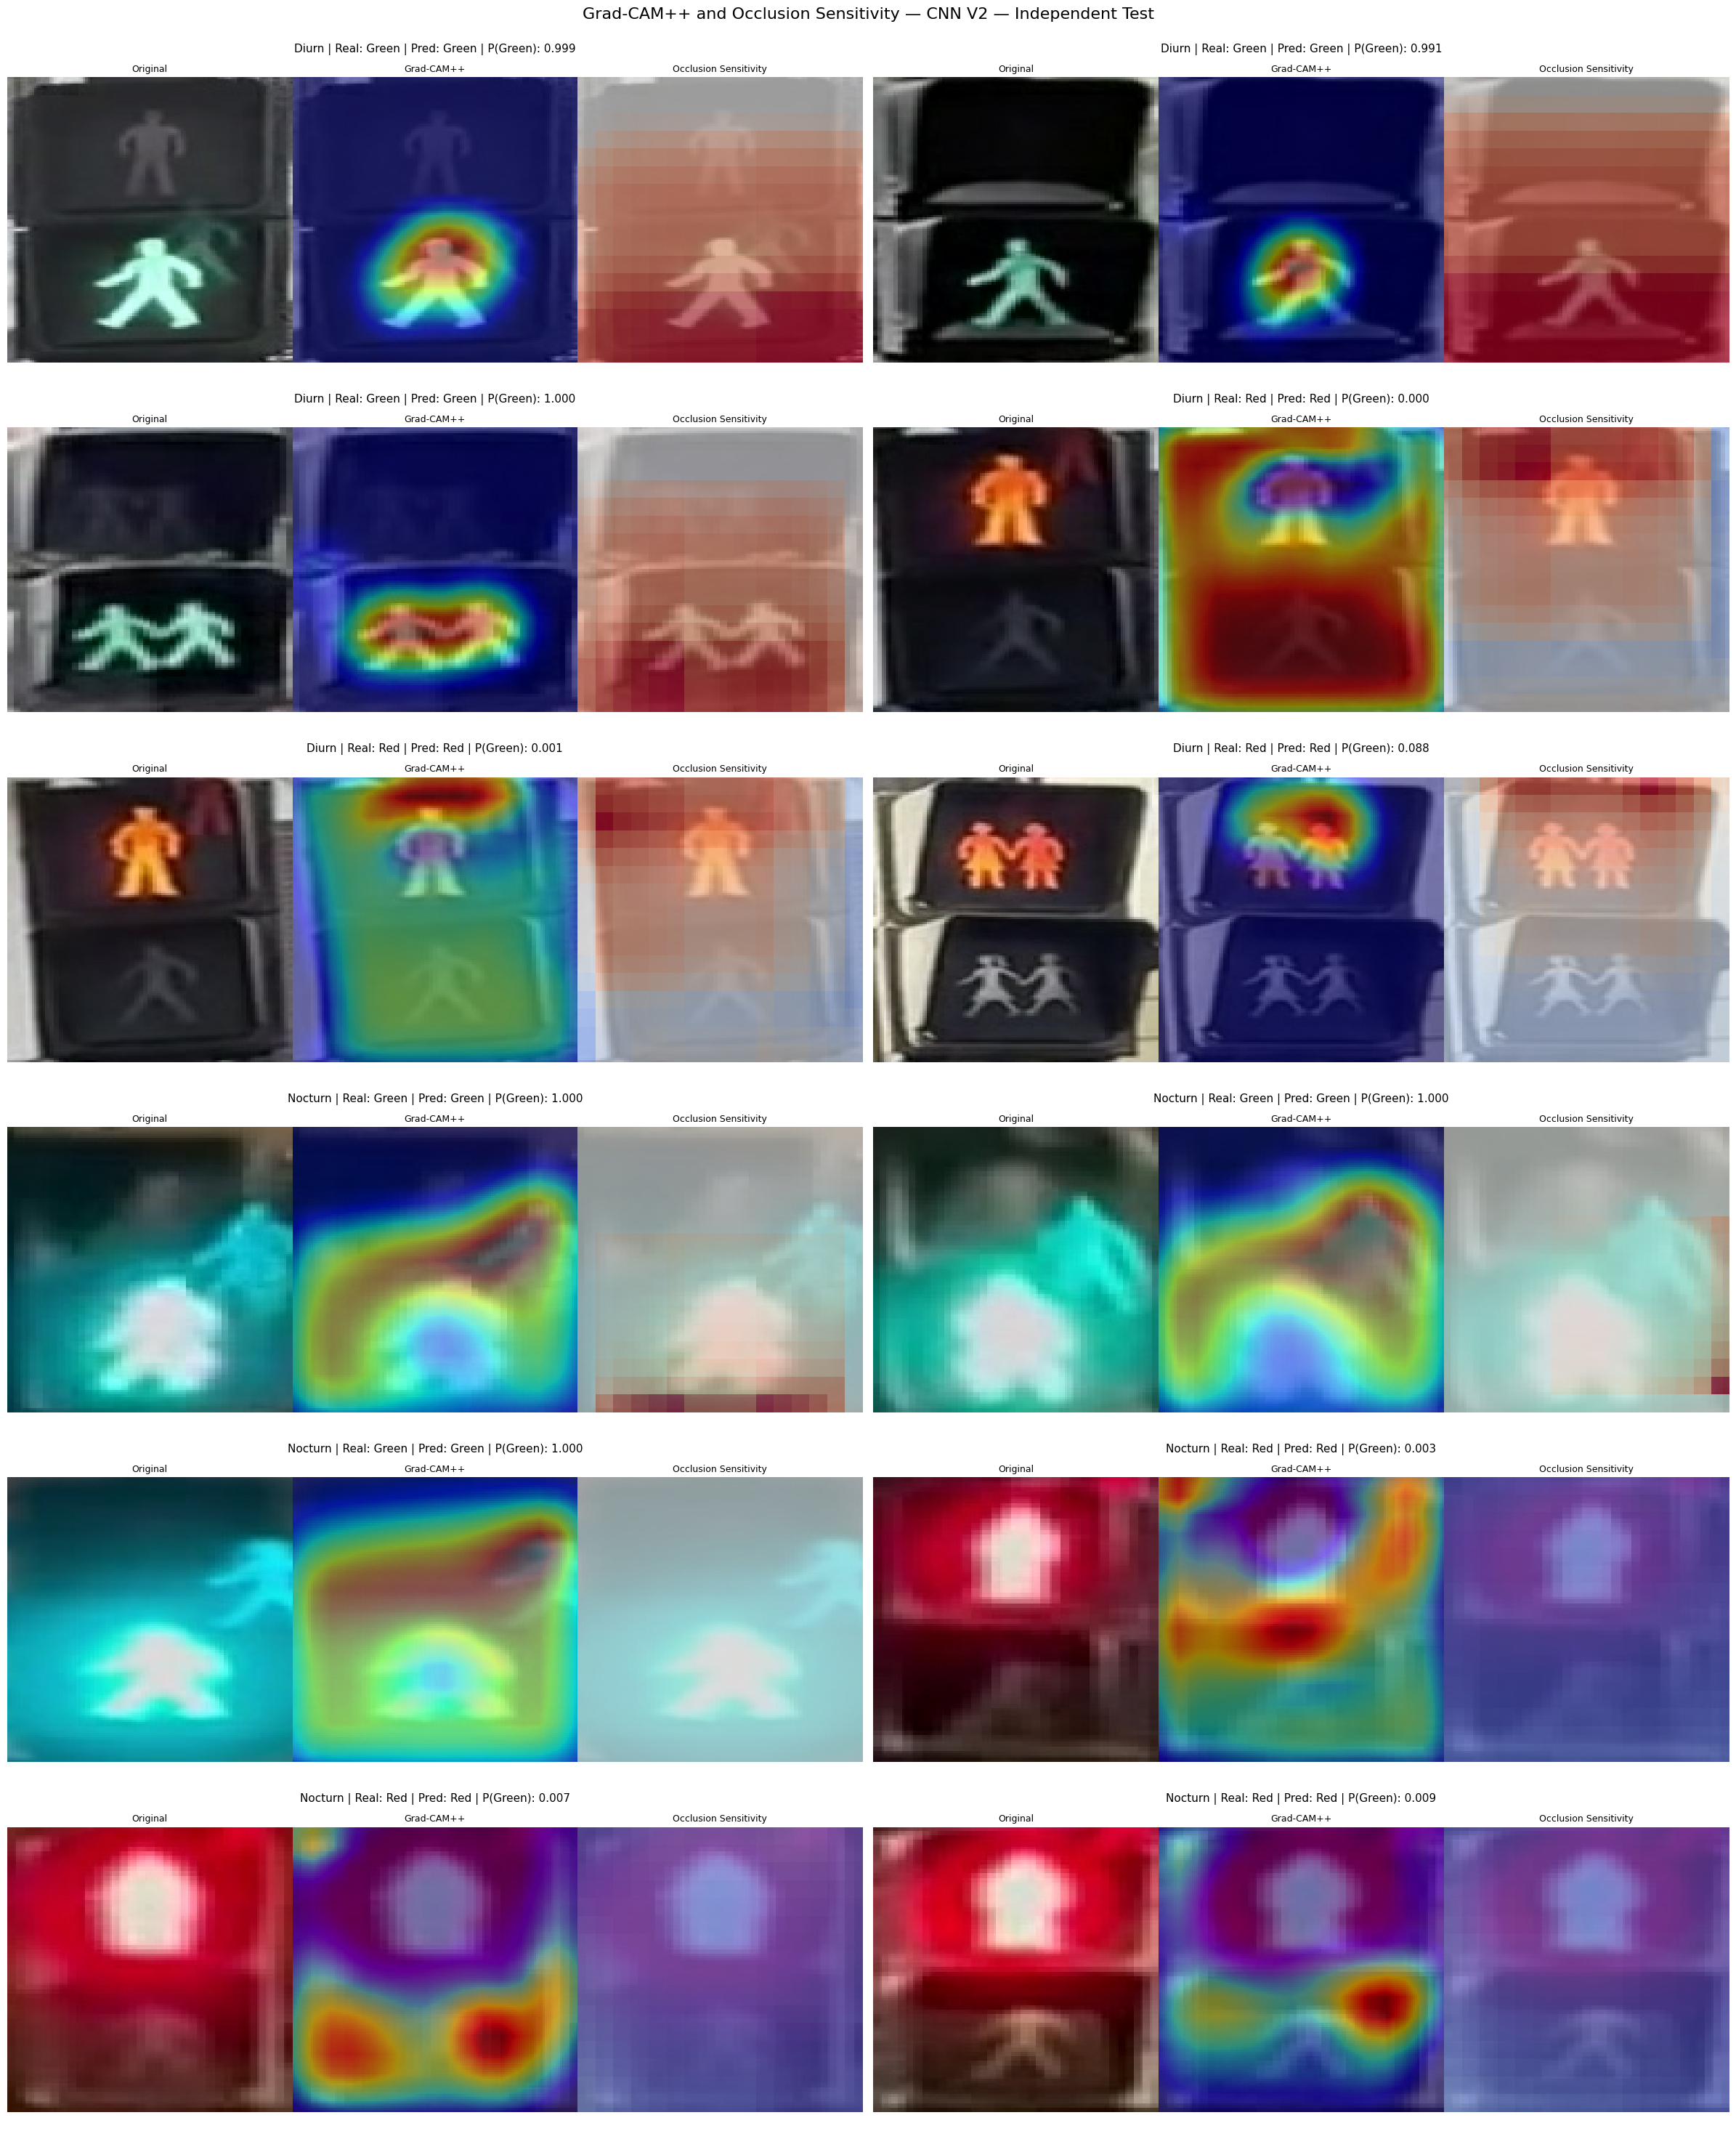

In [36]:
# ============================================================
# CONFIGURATION
# ============================================================

DATASET_VERSION = "dataset_v2"
IMAGE_SIZE = (128, 128)
N_PER_GROUP = 3
COLS = 2

OCCLUSION_SIZE = 80
OCCLUSION_STRIDE = 8
OCCLUSION_BATCH_SIZE = 64
OCCLUSION_VALUE = np.zeros(3, dtype=np.float32)


# ============================================================
# MODEL AND GRAD-CAM++
# ============================================================

model = tf.keras.models.load_model(MODEL_PATH)

conv_layers = [
    layer.name
    for layer in model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]
PENULTIMATE_LAYER = conv_layers[-1]

gradcam = GradcamPlusPlus(
    model=model,
    model_modifier=ReplaceToLinear(),
    clone=True,
)

print(f"Grad-CAM layer: {PENULTIMATE_LAYER}")


# ============================================================
# TEST PREDICTIONS
# ============================================================

test_frames = []

for test_type in ("diurn", "nocturn"):
    predictions = pd.read_csv(
        TEST_PREDICTION_PATHS[f"{DATASET_VERSION}_{test_type}"]
    )
    predictions["test_type"] = test_type
    predictions["filepath"] = [
        CLASSIFIER_TEST_DIR / test_type / true_class / filename
        for true_class, filename in zip(
            predictions["true_class"],
            predictions["filename"],
        )
    ]
    test_frames.append(predictions)

df_test = pd.concat(test_frames, ignore_index=True)
df_correct = df_test[df_test["error_type"] == "correct"].copy()

samples = [
    group.sample(
        n=min(N_PER_GROUP, len(group)),
        random_state=42,
    )
    for _, group in df_correct.groupby(
        ["test_type", "true_class"],
        sort=False,
    )
]
df_samples = pd.concat(samples, ignore_index=True)


# ============================================================
# HELPERS
# ============================================================

def load_image(image_path):
    """Carga la imagen como image_dataset_from_directory() en las métricas."""
    image = tf.io.decode_image(
        tf.io.read_file(str(image_path)),
        channels=3,
        expand_animations=False,
    )
    return tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear",
    ).numpy()


def predicted_class_score(probability_green, predicted_label):
    return (
        probability_green
        if predicted_label == 1
        else 1.0 - probability_green
    )


def calculate_occlusion_map(
    image,
    predicted_label,
    probability_green,
):
    height, width = image.shape[:2]
    regions = [
        (y, x)
        for y in range(
            0,
            height - OCCLUSION_SIZE + 1,
            OCCLUSION_STRIDE,
        )
        for x in range(
            0,
            width - OCCLUSION_SIZE + 1,
            OCCLUSION_STRIDE,
        )
    ]

    occluded_images = np.repeat(
        image[np.newaxis, ...],
        len(regions),
        axis=0,
    )

    for occluded_image, (y, x) in zip(
        occluded_images,
        regions,
    ):
        occluded_image[
            y:y + OCCLUSION_SIZE,
            x:x + OCCLUSION_SIZE,
        ] = OCCLUSION_VALUE

    occluded_probabilities = model.predict(
        occluded_images,
        batch_size=OCCLUSION_BATCH_SIZE,
        verbose=0,
    ).ravel()

    original_score = predicted_class_score(
        probability_green,
        predicted_label,
    )
    occluded_scores = predicted_class_score(
        occluded_probabilities,
        predicted_label,
    )
    score_changes = original_score - occluded_scores

    occlusion_map = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros_like(occlusion_map)

    for (y, x), score_change in zip(
        regions,
        score_changes,
    ):
        region = np.s_[
            y:y + OCCLUSION_SIZE,
            x:x + OCCLUSION_SIZE,
        ]
        occlusion_map[region] += score_change
        counts[region] += 1

    occlusion_map = np.divide(
        occlusion_map,
        counts,
        out=np.zeros_like(occlusion_map),
        where=counts != 0,
    )

    max_abs = np.max(np.abs(occlusion_map))
    if max_abs > 0:
        occlusion_map /= max_abs

    return occlusion_map, score_changes


# ============================================================
# FIGURE
# ============================================================

n_images = len(df_samples)
n_rows = int(np.ceil(n_images / COLS))

fig = plt.figure(
    figsize=(12 * COLS, 5 * n_rows)
)


# ============================================================
# ANALYSIS
# ============================================================

for index, (_, row) in enumerate(df_samples.iterrows()):
    image = load_image(row["filepath"])
    image_input = tf.expand_dims(image, axis=0)

    predicted_label = int(row["predicted_label"])
    probability_green = float(row["probability_green"])

    cam = gradcam(
        BinaryScore(bool(predicted_label)),
        image_input,
        penultimate_layer=PENULTIMATE_LAYER,
    )
    gradcam_heatmap = np.uint8(
        cm.jet(cam[0])[..., :3] * 255
    )

    occlusion_map, score_changes = calculate_occlusion_map(
        image,
        predicted_label,
        probability_green,
    )

    original_score = predicted_class_score(
        probability_green,
        predicted_label,
    )
    print(
        f"{row['test_type'].capitalize()} | "
        f"{row['true_class']} | "
        f"Original score: {original_score:.6f} | "
        f"Max drop: {score_changes.max():.6f} | "
        f"Min drop: {score_changes.min():.6f} | "
        f"Mean abs change: "
        f"{np.mean(np.abs(score_changes)):.6f}"
    )

    image_uint8 = image.astype(np.uint8)
    outer = fig.add_subplot(n_rows, COLS, index + 1)
    outer.axis("off")
    outer.set_title(
        f"{row['test_type'].capitalize()} | "
        f"Real: {row['true_class']} | "
        f"Pred: {row['predicted_class']} | "
        f"P(Green): {probability_green:.3f}",
        fontsize=11,
    )

    panels = [
        ("Original", None, {}),
        ("Grad-CAM++", gradcam_heatmap, {"alpha": 0.5}),
        (
            "Occlusion Sensitivity",
            occlusion_map,
            {
                "cmap": "coolwarm",
                "alpha": 0.65,
                "vmin": -1,
                "vmax": 1,
            },
        ),
    ]

    for panel_index, (title, overlay, options) in enumerate(panels):
        axis = outer.inset_axes(
            [panel_index / 3, 0, 1 / 3, 1]
        )
        axis.imshow(image_uint8)

        if overlay is not None:
            axis.imshow(overlay, **options)

        axis.set_title(title, fontsize=9)
        axis.axis("off")


fig.suptitle(
    "Grad-CAM++ and Occlusion Sensitivity — CNN V2 — Independent Test",
    fontsize=16,
)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

# Grad-CAM temporal — GIF y vídeo

Genera una secuencia temporal a partir de los recortes del mismo vídeo del test independiente. Cada frame muestra el Grad-CAM a la izquierda y el recorte original a la derecha.

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

VIDEO_ID = "000158"  # None selecciona automáticamente el vídeo con más frames
TEST_TYPE = "nocturn"  # None permite buscar en diurno y nocturno
IMAGE_SIZE = (128, 128)

FRAME_STEP = 1
MAX_FRAMES = 60
PLAYBACK_FPS = 2  # Menor valor = reproducción más lenta

CNN_THRESHOLD = 0.8
GRADCAM_ALPHA = 0.5
GRADCAM_LAYERS = [-7, -5, -3, -1]  # Índices o nombres de capas Conv2D
OUTPUT_SCALE = 2

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png"}


# ============================================================
# FIND AND SORT VIDEO FRAMES
# ============================================================

def parse_video_frame(image_path):
    stem = image_path.stem

    if "_frame" not in stem:
        return None

    video_id, frame_suffix = stem.split("_frame", maxsplit=1)
    frame_text = frame_suffix.split("_", maxsplit=1)[0]

    if not frame_text.isdigit():
        return None

    return video_id, int(frame_text)


video_sequences = {}

for image_path in CLASSIFIER_TEST_DIR.rglob("*"):
    if (
        not image_path.is_file()
        or image_path.suffix.lower() not in SUPPORTED_EXTENSIONS
    ):
        continue

    parsed_frame = parse_video_frame(image_path)
    if parsed_frame is None:
        continue

    video_id, frame_number = parsed_frame
    relative_path = image_path.relative_to(CLASSIFIER_TEST_DIR)
    test_type = relative_path.parts[0]
    sequence_key = (test_type, video_id)

    video_sequences.setdefault(sequence_key, []).append(
        (frame_number, image_path)
    )


candidate_sequences = {
    sequence_key: frames
    for sequence_key, frames in video_sequences.items()
    if (
        (VIDEO_ID is None or sequence_key[1] == VIDEO_ID)
        and (TEST_TYPE is None or sequence_key[0] == TEST_TYPE)
    )
}

if not candidate_sequences:
    raise ValueError(
        f"No hay frames para VIDEO_ID={VIDEO_ID!r} "
        f"y TEST_TYPE={TEST_TYPE!r}."
    )

selected_key = max(
    candidate_sequences,
    key=lambda key: len(candidate_sequences[key]),
)
selected_test_type, selected_video_id = selected_key

ordered_frames = sorted(
    candidate_sequences[selected_key],
    key=lambda item: (item[0], item[1].name),
)[::FRAME_STEP]

if MAX_FRAMES is not None:
    ordered_frames = ordered_frames[:MAX_FRAMES]

print(
    f"Vídeo seleccionado: {selected_video_id} "
    f"({selected_test_type}) — {len(ordered_frames)} frames"
)


# ============================================================
# MODEL AND GRAD-CAM++
# ============================================================

model = tf.keras.models.load_model(MODEL_PATH)

conv_layers = [
    layer.name
    for layer in model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]
gradcam_layers = []

for layer_reference in GRADCAM_LAYERS:
    layer_name = (
        conv_layers[layer_reference]
        if isinstance(layer_reference, int)
        else layer_reference
    )

    if layer_name not in conv_layers:
        raise ValueError(
            f"La capa {layer_name!r} no es una capa Conv2D."
        )

    if layer_name not in gradcam_layers:
        gradcam_layers.append(layer_name)

print(f"Grad-CAM layers: {gradcam_layers}")

gradcam = GradcamPlusPlus(
    model=model,
    model_modifier=ReplaceToLinear(),
    clone=True,
)


# ============================================================
# BUILD COMPOSITE FRAMES
# ============================================================

def build_gradcam_frame(frame_number, image_path):
    # Misma carga que image_dataset_from_directory() en las métricas.
    image = tf.io.decode_image(
        tf.io.read_file(str(image_path)),
        channels=3,
        expand_animations=False,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear",
    ).numpy()
    image_input = tf.expand_dims(image, axis=0)

    probability_green = float(
        model.predict(image_input, verbose=0)[0][0]
    )
    predicted_label = int(
        probability_green >= CNN_THRESHOLD
    )
    predicted_class = (
        "Green" if predicted_label == 1 else "Red"
    )

    original = Image.fromarray(
        image.astype(np.uint8)
    ).convert("RGB")

    gradcam_overlays = []

    for layer_name in gradcam_layers:
        cam = gradcam(
            BinaryScore(bool(predicted_label)),
            image_input,
            penultimate_layer=layer_name,
        )[0]

        heatmap = Image.fromarray(
            np.uint8(cm.jet(cam)[..., :3] * 255)
        ).convert("RGB")
        gradcam_overlays.append(
            Image.blend(
                original,
                heatmap,
                alpha=GRADCAM_ALPHA,
            )
        )

    header_height = 24
    footer_height = 24
    width, height = original.size
    panels = [("Original", original)] + [
        (f"Grad-CAM: {layer_name}", overlay)
        for layer_name, overlay in zip(
            gradcam_layers,
            gradcam_overlays,
        )
    ]

    composite = Image.new(
        "RGB",
        (
            width * len(panels),
            header_height + height + footer_height,
        ),
        color=(20, 20, 20),
    )
    for panel_index, (_, panel_image) in enumerate(panels):
        composite.paste(
            panel_image,
            (panel_index * width, header_height),
        )

    drawing = ImageDraw.Draw(composite)
    prediction_color = (
        (35, 150, 70)
        if predicted_label == 1
        else (190, 45, 45)
    )
    footer_top = header_height + height
    drawing.rectangle(
        (
            0,
            footer_top,
            width * len(panels),
            footer_top + footer_height,
        ),
        fill=prediction_color,
    )

    for panel_index, (panel_title, _) in enumerate(panels):
        drawing.text(
            (panel_index * width + 6, 5),
            panel_title,
            fill="white",
        )
    drawing.text(
        (6, header_height + height + 5),
        (
            f"Frame {frame_number:06d} | "
            f"P(Green): {probability_green:.3f} | "
            f"Pred: {predicted_class}"
        ),
        fill="white",
    )

    if OUTPUT_SCALE != 1:
        composite = composite.resize(
            (
                composite.width * OUTPUT_SCALE,
                composite.height * OUTPUT_SCALE,
            ),
            resample=Image.Resampling.BICUBIC,
        )

    return np.asarray(composite)


composite_frames = [
    build_gradcam_frame(frame_number, image_path)
    for frame_number, image_path in ordered_frames
]


# ============================================================
# EXPORT GIF
# ============================================================

REPORT_DIR.mkdir(parents=True, exist_ok=True)

output_stem = (
    f"cnn_gradcam_{selected_test_type}_{selected_video_id}"
)
gif_path = REPORT_DIR / f"{output_stem}.gif"
video_path = REPORT_DIR / f"{output_stem}.mp4"

gif_images = [
    Image.fromarray(frame)
    for frame in composite_frames
]
gif_images[0].save(
    gif_path,
    save_all=True,
    append_images=gif_images[1:],
    duration=round(1000 / PLAYBACK_FPS),
    loop=0,
    disposal=2,
)


# ============================================================
# EXPORT MP4
# ============================================================

frame_height, frame_width = composite_frames[0].shape[:2]

video_figure = plt.figure(
    figsize=(frame_width / 100, frame_height / 100),
    dpi=100,
)
video_axis = video_figure.add_axes([0, 0, 1, 1])
video_axis.axis("off")
video_artist = video_axis.imshow(composite_frames[0])

video_writer = FFMpegWriter(
    fps=PLAYBACK_FPS,
    codec="libx264",
    extra_args=["-pix_fmt", "yuv420p"],
)

with video_writer.saving(
    video_figure,
    str(video_path),
    dpi=100,
):
    for frame in composite_frames:
        video_artist.set_data(frame)
        video_writer.grab_frame()

plt.close(video_figure)


# ============================================================
# RESULTS
# ============================================================

print(f"GIF guardado en: {gif_path}")
print(f"Vídeo guardado en: {video_path}")

display(IPythonImage(filename=str(gif_path)))
display(Video(str(video_path), embed=True))

Vídeo seleccionado: 000158 (nocturn) — 59 frames
Grad-CAM layers: ['conv_2', 'conv_4', 'conv_6', 'conv_8']
